# Multimodal PatchTST — TEP Dataset
### EDA -> Preprocessing -> Baseline Model -> Confidence-Aware Model -> Evaluation

**Pipeline:**
1. Imports & Config
2. Data Loading
3. EDA (7 steps)
4. Preprocessing & DataLoaders
5. Baseline Model Architecture
6. Baseline Training
7. Baseline Evaluation
8. Per-Modality Embedding Analysis
9. Save Baseline
10. Confidence-Aware Model
11. Confidence-Aware Training
12. Confidence-Aware Evaluation
13. Confidence Weight Analysis
14. Save Confidence-Aware Model


---
## 1. Imports & Config

In [17]:
import numpy as np
import pandas as pd
import os
import warnings
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

print('PyTorch:', torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', device)

PyTorch: 2.10.0+cu128
Device : cuda


In [18]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH = '/content/sample_data/TEP_Data'

# ── Windowing ─────────────────────────────────────────────────────────────────
WINDOW_SIZE = 80
STRIDE      = 2
NUM_CLASSES = 22

# ── Modality groups (0-indexed over 52 TEP variables) ─────────────────────────
MODALITY_GROUPS = {
    'Reactor':     list(range(0,  9)),
    'Separator':   list(range(9,  14)),
    'Stripper':    list(range(14, 22)),
    'Composition': list(range(22, 52)),
}
MODALITY_DIMS = {g: len(idx) for g, idx in MODALITY_GROUPS.items()}

# ── PatchTST hyperparameters ──────────────────────────────────────────────────
PATCH_LEN  = 8
D_MODEL    = 128
NUM_HEADS  = 4
NUM_LAYERS = 3
DROPOUT    = 0.1

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE = 64
EPOCHS     = 20
LR         = 1e-3

# ── Labels & names ────────────────────────────────────────────────────────────
SENSOR_NAMES = [
    'A Feed','D Feed','E Feed','A+C Feed','Recycle','Reactor Feed Rate',
    'Reactor Pressure','Reactor Level','Reactor Temp',
    'Purge Rate','Sep Temp','Sep Level','Sep Pressure','Sep Underflow',
    'Stripper Level','Stripper Pressure','Stripper Underflow','Stripper Temp',
    'Stripper Steam','Compressor Work','Reactor CW Outlet','Condenser CW Outlet',
    'D in Feed(s6)','E in Feed(s6)','A in Feed(s6)',
    'A in Purge','B in Purge','C in Purge','D in Purge','E in Purge','F in Purge',
    'D in Product','E in Product','F in Product',
    'D Feed Valve','E Feed Valve','A Feed Valve','A+C Feed Valve',
    'Comp Recycle Valve','Purge Valve','Sep Liquid Valve',
    'Strip Liquid Valve','Strip Steam Valve','Reactor CW Valve','Cond CW Valve',
    'Agitator Speed',
    'A in S4','B in S4','C in S4','D in S4','F in S4','G in S4',
]
while len(SENSOR_NAMES) < 52:
    SENSOR_NAMES.append(f'Var_{len(SENSOR_NAMES)+1}')
SENSOR_NAMES = SENSOR_NAMES[:52]

FAULT_LABELS = {
    0:'Normal', 1:'A/C ratio', 2:'B composition', 3:'D feed temp',
    4:'Reactor CW temp', 5:'Condenser CW temp', 6:'A feed loss',
    7:'C header pressure', 8:'A/B/C composition', 9:'D feed temp (rand)',
    10:'C feed temp', 11:'Reactor CW temp (rand)', 12:'Condenser CW temp (rand)',
    13:'Reaction kinetics', 14:'Reactor CW valve', 15:'Condenser CW valve',
    16:'Unknown A/C ratio', 17:'Unknown B composition', 18:'Unknown A feed temp',
    19:'Unknown D feed valve', 20:'Unknown C feed temp', 21:'Valve fault',
}

GROUP_COLORS = {
    'Reactor':'#4a90d9','Separator':'#e8a838',
    'Stripper':'#4caf7d','Composition':'#e05c5c'
}

print('Config ready. Modality dims:', MODALITY_DIMS)

Config ready. Modality dims: {'Reactor': 9, 'Separator': 5, 'Stripper': 8, 'Composition': 30}


---
## 2. Data Loading

In [19]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Load function (improved)
# -----------------------------
def load_dat(filepath):
    data = pd.read_csv(filepath, sep=r'\s+', header=None).values.astype(np.float32)

    # Fix orientation if needed
    if data.shape[0] == 52 and data.shape[1] != 52:
        data = data.T

    # Sanity check
    if data.shape[1] != 52:
        raise ValueError(f"Unexpected shape {data.shape} in {filepath}")

    return data  # (T, 52)


# -----------------------------
# 2. Windowing (safer)
# -----------------------------
def create_windows(X, y, window_size=80, stride=2, method="majority"):
    X_windows, y_windows = [], []

    for i in range(0, len(X) - window_size + 1, stride):
        window = X[i:i + window_size]

        # Since label is scalar in your pipeline
        label = y

        X_windows.append(window)
        y_windows.append(label)

    return np.array(X_windows, dtype=np.float32), np.array(y_windows, dtype=np.int64)


# -----------------------------
# 3. File list
# -----------------------------
file_list = [(f'd{i:02d}.dat', i) for i in range(22)] + \
            [(f'd{i:02d}_te.dat', i) for i in range(1, 22)]


# -----------------------------
# 4. Storage
# -----------------------------
raw_data = {}

X_train_all, y_train_all = [], []
X_val_all,   y_val_all   = [], []
X_test_all,  y_test_all  = [], []

summary_rows = []


# -----------------------------
# 5. Main loop (IMPROVED)
# -----------------------------
for filename, label in file_list:
    path = os.path.join(DATA_PATH, filename)

    if not os.path.exists(path):
        summary_rows.append({'file': filename, 'label': label,
                             'rows': None, 'nan': None, 'inf': None})
        continue

    # Load
    data = load_dat(path)
    df   = pd.DataFrame(data, columns=SENSOR_NAMES)
    raw_data.setdefault(label, []).append(df)

    # Data quality
    nan_c = df.isna().sum().sum()
    inf_c = np.isinf(data).sum()

    summary_rows.append({
        'file': filename,
        'label': label,
        'rows': data.shape[0],
        'nan': nan_c,
        'inf': inf_c
    })

    # -----------------------------
    # SPLIT (Train / Val / Test)
    # -----------------------------
    n = len(data)
    train_end = int(n * 0.7)
    val_end   = int(n * 0.85)

    train_data = data[:train_end]
    val_data   = data[train_end:val_end]
    test_data  = data[val_end:]

    # -----------------------------
    # WINDOWING
    # -----------------------------
    Xtr, ytr = create_windows(train_data, label)
    Xval, yval = create_windows(val_data, label)
    Xte, yte = create_windows(test_data, label)

    # Only append non-empty window sets
    if len(Xtr) > 0:
        X_train_all.append(Xtr); y_train_all.append(ytr)
    if len(Xval) > 0:
        X_val_all.append(Xval);  y_val_all.append(yval)
    if len(Xte) > 0:
        X_test_all.append(Xte);  y_test_all.append(yte)


# -----------------------------
# 6. CONCATENATE
# -----------------------------
# Ensure there are arrays to concatenate, otherwise create an empty array of correct dimensions
X_train = np.concatenate(X_train_all) if len(X_train_all) > 0 else np.array([], dtype=np.float32).reshape(0, WINDOW_SIZE, 52)
X_val   = np.concatenate(X_val_all)   if len(X_val_all) > 0   else np.array([], dtype=np.float32).reshape(0, WINDOW_SIZE, 52)
X_test  = np.concatenate(X_test_all)  if len(X_test_all) > 0  else np.array([], dtype=np.float32).reshape(0, WINDOW_SIZE, 52)

y_train = np.concatenate(y_train_all) if len(y_train_all) > 0 else np.array([], dtype=np.int64).reshape(0)
y_val   = np.concatenate(y_val_all)   if len(y_val_all) > 0   else np.array([], dtype=np.int64).reshape(0)
y_test  = np.concatenate(y_test_all)  if len(y_test_all) > 0  else np.array([], dtype=np.int64).reshape(0)


# -----------------------------
# 7. SCALING (VERY IMPORTANT)
# -----------------------------
scaler = StandardScaler()

# Fit ONLY on training data if X_train is not empty
if X_train.shape[0] > 0:
    X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
    scaler.fit(X_train_reshaped)
else:
    print("Warning: X_train is empty. Skipping scaler fitting.")

# Transform all sets
def scale_data(X):
    if X.shape[0] == 0:
        return X # Return empty array as is
    X_reshaped = X.reshape(-1, X.shape[-1])
    X_scaled = scaler.transform(X_reshaped)
    return X_scaled.reshape(X.shape)

X_train = scale_data(X_train)
X_val   = scale_data(X_val)
X_test  = scale_data(X_test)


# -----------------------------
# 8. SUMMARY
# -----------------------------
summary_df = pd.DataFrame(summary_rows)

print(summary_df.to_string(index=False))

print("\nDataset Shapes:")
print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

print(f"\nTotal NaNs: {summary_df['nan'].sum()}")
print(f"Total Infs: {summary_df['inf'].sum()}")

      file  label  rows  nan  inf
   d00.dat      0   500    0    0
   d01.dat      1   480    0    0
   d02.dat      2   480    0    0
   d03.dat      3   480    0    0
   d04.dat      4   480    0    0
   d05.dat      5   480    0    0
   d06.dat      6   480    0    0
   d07.dat      7   480    0    0
   d08.dat      8   480    0    0
   d09.dat      9   480    0    0
   d10.dat     10   480    0    0
   d11.dat     11   480    0    0
   d12.dat     12   480    0    0
   d13.dat     13   480    0    0
   d14.dat     14   480    0    0
   d15.dat     15   480    0    0
   d16.dat     16   480    0    0
   d17.dat     17   480    0    0
   d18.dat     18   480    0    0
   d19.dat     19   480    0    0
   d20.dat     20   480    0    0
   d21.dat     21   480    0    0
d01_te.dat      1   960    0    0
d02_te.dat      2   960    0    0
d03_te.dat      3   960    0    0
d04_te.dat      4   960    0    0
d05_te.dat      5   960    0    0
d06_te.dat      6   960    0    0
d07_te.dat    

---
## 3. EDA
### Step 1 — Per-feature statistics (normal operation)

In [20]:
P_normal_df = pd.concat(raw_data[0])
all_df    = pd.concat([pd.concat(dfs) for dfs in raw_data.values()])

stats = P_normal_df.describe().T[['min','mean','max','std']].round(3)
print('Feature statistics — Normal operation (class 0)')
print(stats.to_string())

Feature statistics — Normal operation (class 0)
                          min      mean       max     std
A Feed                  0.181     0.251     0.343   0.029
D Feed               3559.500  3663.538  3754.700  32.032
E Feed               4419.800  4511.517  4600.700  31.725
A+C Feed                9.129     9.344     9.593   0.077
Recycle                26.280    26.908    27.529   0.209
Reactor Feed Rate      41.659    42.339    42.925   0.221
Reactor Pressure     2690.500  2705.397  2715.800   5.263
Reactor Level          73.617    74.985    76.750   0.528
Reactor Temp          120.350   120.399   120.450   0.019
Purge Rate              0.305     0.338     0.370   0.012
Sep Temp               79.423    80.092    80.679   0.194
Sep Level              47.240    50.064    53.178   1.034
Sep Pressure         2619.200  2634.174  2645.000   5.533
Sep Underflow          21.877    25.120    28.660   1.064
Stripper Level         46.962    49.991    52.859   1.018
Stripper Pressure    308

### Step 2 — Class Distribution

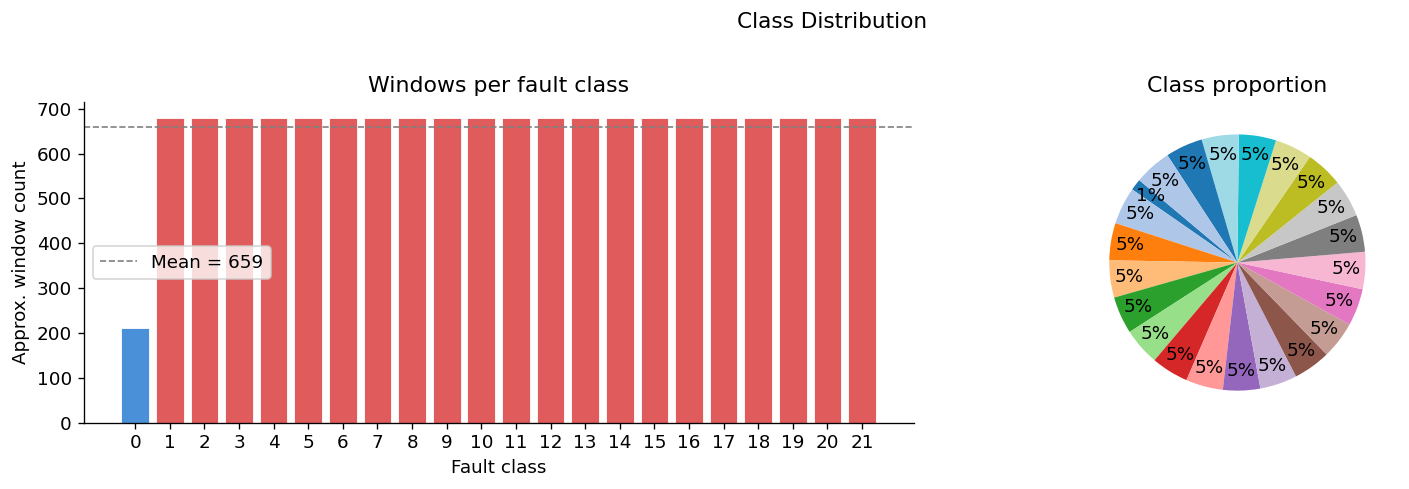

Window counts per class:
   0  Normal                        :   210
   1  A/C ratio                     :   680
   2  B composition                 :   680
   3  D feed temp                   :   680
   4  Reactor CW temp               :   680
   5  Condenser CW temp             :   680
   6  A feed loss                   :   680
   7  C header pressure             :   680
   8  A/B/C composition             :   680
   9  D feed temp (rand)            :   680
  10  C feed temp                   :   680
  11  Reactor CW temp (rand)        :   680
  12  Condenser CW temp (rand)      :   680
  13  Reaction kinetics             :   680
  14  Reactor CW valve              :   680
  15  Condenser CW valve            :   680
  16  Unknown A/C ratio             :   680
  17  Unknown B composition         :   680
  18  Unknown A feed temp           :   680
  19  Unknown D feed valve          :   680
  20  Unknown C feed temp           :   680
  21  Valve fault                   :   680


In [21]:
window_counts = {}
for label, dfs in raw_data.items():
    total = sum(len(d) for d in dfs)
    window_counts[label] = max(0, (total - WINDOW_SIZE) // STRIDE)

labels_sorted = sorted(window_counts)
counts  = [window_counts[l] for l in labels_sorted]
colors  = ['#4a90d9' if l == 0 else '#e05c5c' for l in labels_sorted]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(labels_sorted, counts, color=colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(np.mean(counts), color='gray', linestyle='--', linewidth=1,
                label=f'Mean = {np.mean(counts):.0f}')
axes[0].set_xlabel('Fault class'); axes[0].set_ylabel('Approx. window count')
axes[0].set_title('Windows per fault class'); axes[0].legend()
axes[0].set_xticks(labels_sorted)

axes[1].pie(counts, autopct='%1.0f%%', startangle=140,
            colors=plt.cm.tab20.colors[:len(labels_sorted)], pctdistance=0.85)
axes[1].set_title('Class proportion')

plt.suptitle('Class Distribution', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eda_01_class_distribution.png', bbox_inches='tight')
plt.show()

print('Window counts per class:')
for l in labels_sorted:
    print(f'  {l:2d}  {FAULT_LABELS[l]:30s}: {window_counts[l]:5d}')

### Step 3 — Per-Sensor Variance

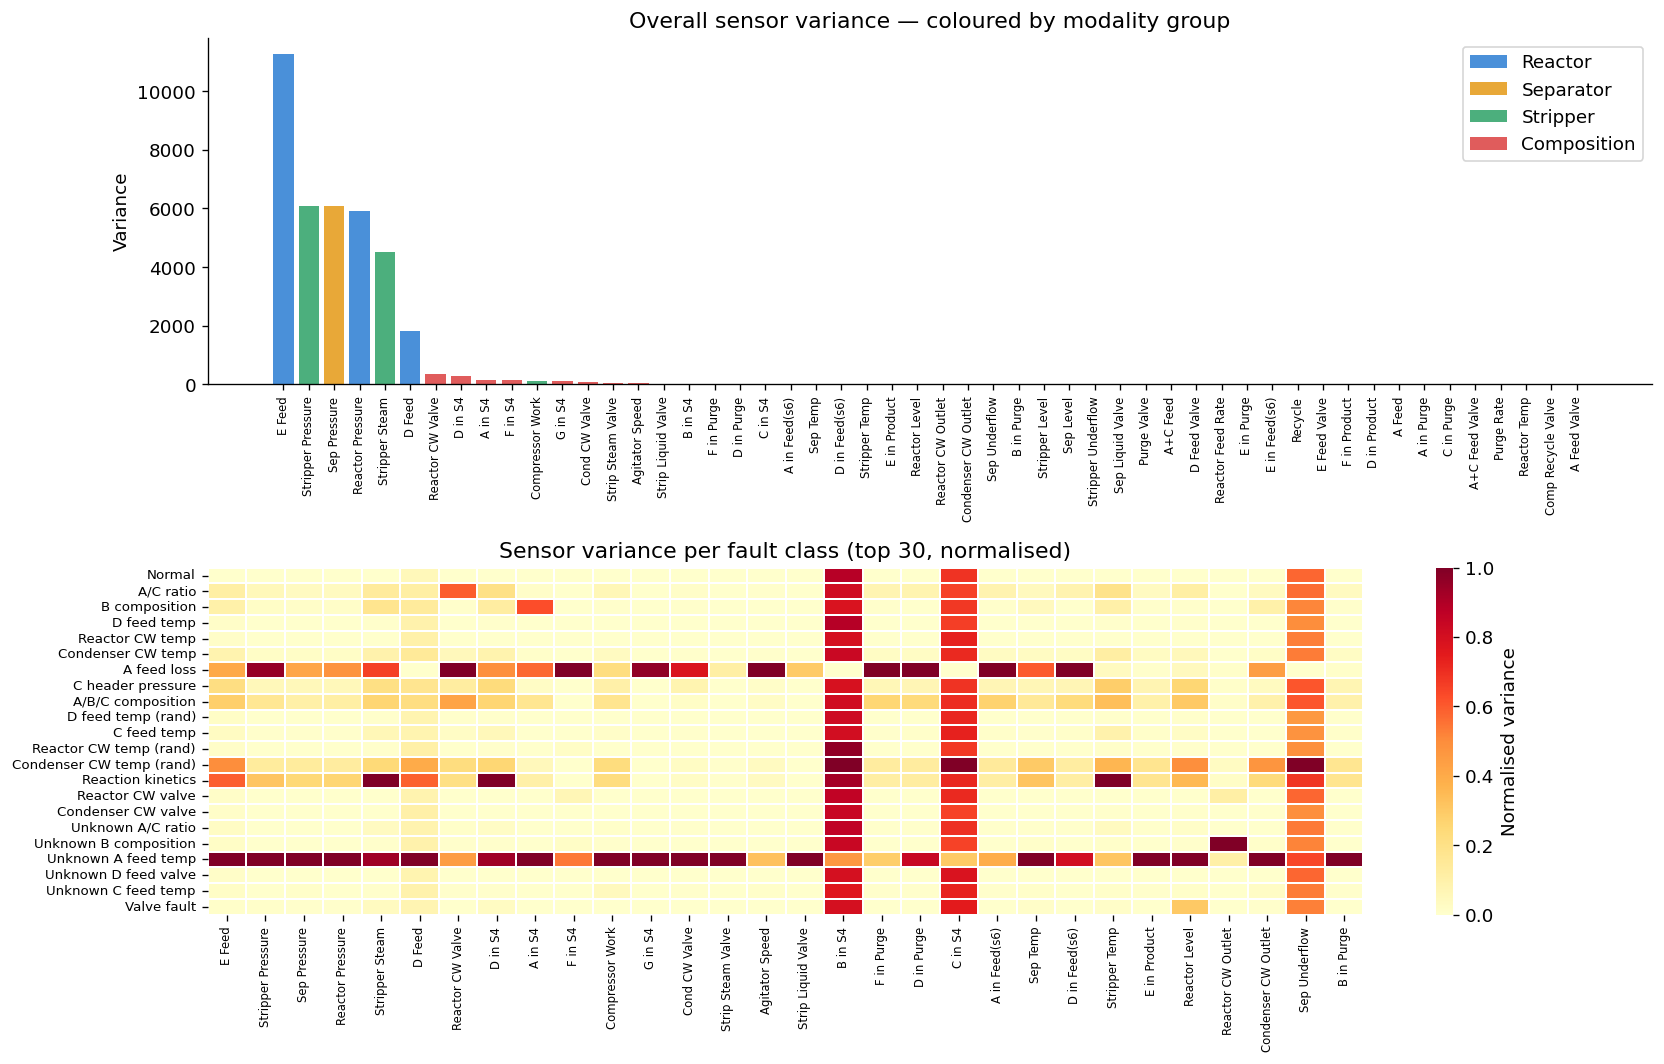

Weakest discriminators (low variance lift):
Sep Level            -0.083
B in S4              -0.083
Sep Underflow        -0.043
C in S4              -0.024
Stripper Level       -0.024
Stripper Underflow   -0.002
Purge Valve           0.057
Recycle               0.192
A Feed Valve          0.206
Sep Liquid Valve      0.325

Strongest discriminators:
Sep Temp               35.790001
Compressor Work        42.653000
Strip Liquid Valve     55.622002
Reactor CW Outlet      65.948997
Sep Pressure           86.621002
Reactor Pressure       90.500999
Stripper Pressure     102.363998
Strip Steam Valve     145.085999
Agitator Speed        176.960999
F in S4               212.156998


In [22]:
var_by_class = {label: pd.concat(dfs).var() for label, dfs in raw_data.items()}
var_df       = pd.DataFrame(var_by_class).T
overall_var  = all_df.var().sort_values(ascending=False)

def sensor_color(name):
    idx = SENSOR_NAMES.index(name)
    for grp, indices in MODALITY_GROUPS.items():
        if idx in indices:
            return GROUP_COLORS[grp]
    return '#aaaaaa'

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

bar_colors = [sensor_color(s) for s in overall_var.index]
axes[0].bar(range(52), overall_var.values, color=bar_colors, edgecolor='none')
axes[0].set_xticks(range(52))
axes[0].set_xticklabels(overall_var.index, rotation=90, fontsize=7)
axes[0].set_ylabel('Variance')
axes[0].set_title('Overall sensor variance — coloured by modality group')
for grp, col in GROUP_COLORS.items():
    axes[0].bar(0, 0, color=col, label=grp)
axes[0].legend(loc='upper right')

top30      = overall_var.head(30).index.tolist()
var_subset = var_df[top30]
var_norm   = (var_subset - var_subset.min()) / (var_subset.max() - var_subset.min() + 1e-9)

sns.heatmap(var_norm, ax=axes[1], cmap='YlOrRd',
            xticklabels=top30,
            yticklabels=[FAULT_LABELS[l] for l in var_df.index],
            cbar_kws={'label': 'Normalised variance'}, linewidths=0.1)
axes[1].set_xticklabels(top30, rotation=90, fontsize=7)
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=8)
axes[1].set_title('Sensor variance per fault class (top 30, normalised)')

plt.tight_layout()
plt.savefig('eda_02_sensor_variance.png', bbox_inches='tight')
plt.show()

# Weak vs strong discriminators
normal_var = var_df.loc[0]
fault_var  = var_df.drop(index=0).mean()
variance_lift = ((fault_var - normal_var) / (normal_var + 1e-9)).sort_values()
print('Weakest discriminators (low variance lift):')
print(variance_lift.head(10).round(3).to_string())
print('\nStrongest discriminators:')
print(variance_lift.tail(10).round(3).to_string())

### Step 4 — Correlation Heatmap

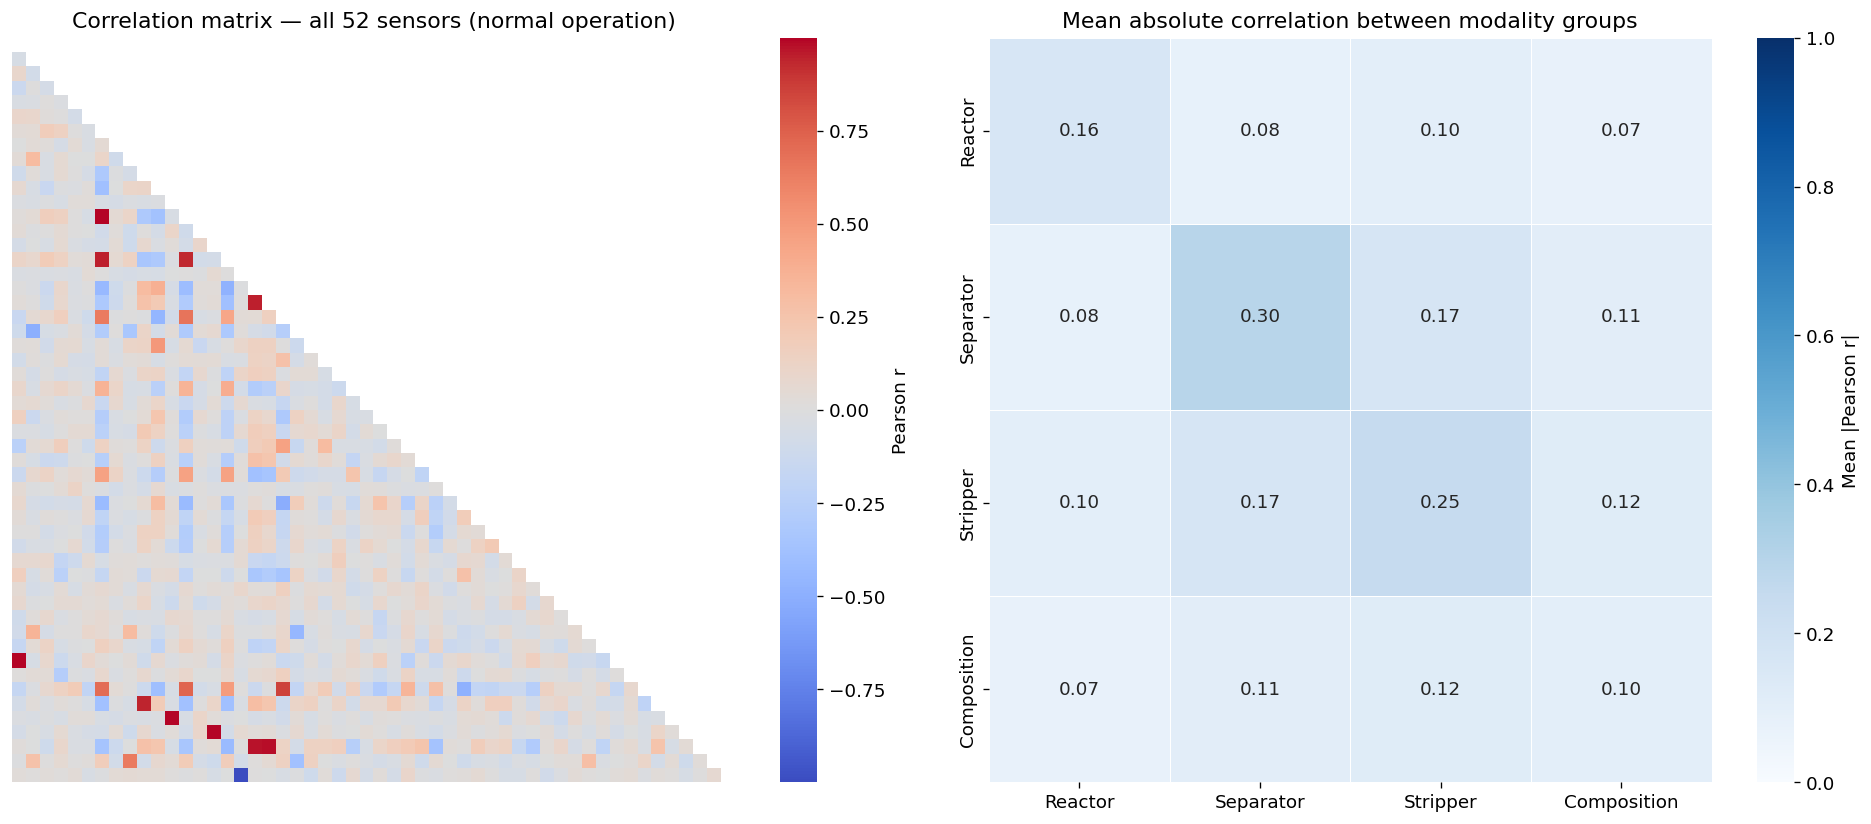

Group correlation matrix:
             Reactor  Separator  Stripper  Composition
Reactor        0.163      0.081     0.099        0.075
Separator      0.081      0.295     0.170        0.107
Stripper       0.099      0.170     0.253        0.117
Composition    0.075      0.107     0.117        0.101

High diagonal = strong intra-group correlation (good grouping).
Low off-diagonal = groups are distinct from each other.


In [23]:
corr = P_normal_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], cmap='coolwarm', center=0,
            mask=mask, xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'Pearson r'}, linewidths=0)
axes[0].set_title('Correlation matrix — all 52 sensors (normal operation)')

group_names = list(MODALITY_GROUPS.keys())
n_g = len(group_names)
group_corr = np.zeros((n_g, n_g))
for i, g1 in enumerate(group_names):
    for j, g2 in enumerate(group_names):
        sub = corr.iloc[MODALITY_GROUPS[g1], MODALITY_GROUPS[g2]]
        group_corr[i, j] = sub.abs().mean().mean()

gcdf = pd.DataFrame(group_corr, index=group_names, columns=group_names)
sns.heatmap(gcdf, ax=axes[1], cmap='Blues', annot=True, fmt='.2f',
            vmin=0, vmax=1, cbar_kws={'label': 'Mean |Pearson r|'}, linewidths=0.5)
axes[1].set_title('Mean absolute correlation between modality groups')

plt.tight_layout()
plt.savefig('eda_03_correlation.png', bbox_inches='tight')
plt.show()

print('Group correlation matrix:')
print(gcdf.round(3).to_string())
print('\nHigh diagonal = strong intra-group correlation (good grouping).')
print('Low off-diagonal = groups are distinct from each other.')

### Step 5 — Time Series Plots

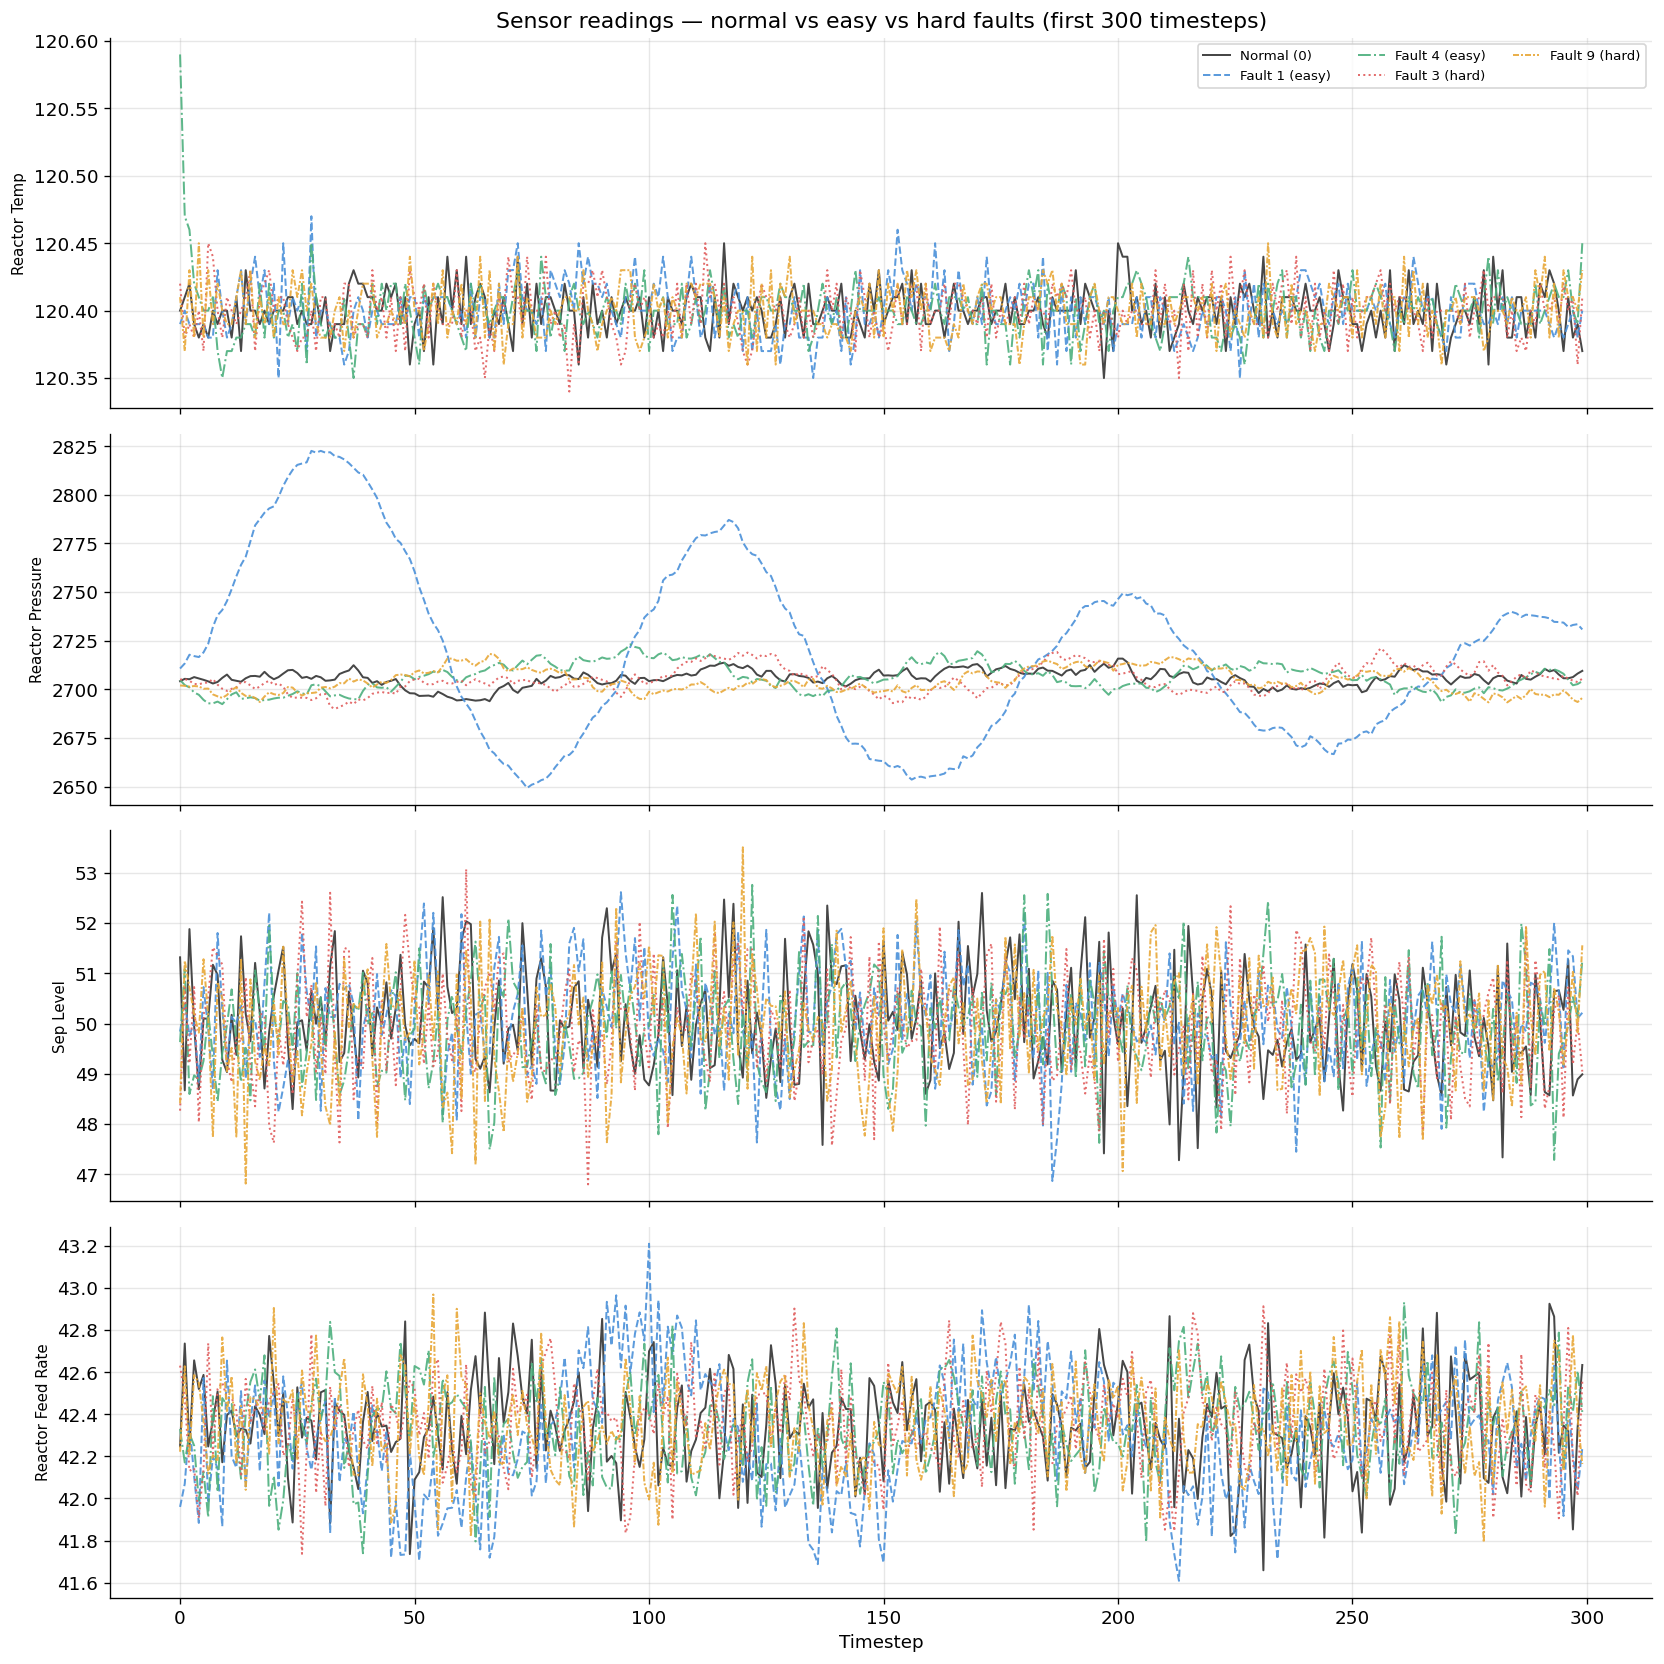

In [24]:
PLOT_SENSORS = ['Reactor Temp', 'Reactor Pressure', 'Sep Level', 'Reactor Feed Rate']
COMPARE = {'Normal (0)': 0, 'Fault 1 (easy)': 1, 'Fault 4 (easy)': 4,
           'Fault 3 (hard)': 3, 'Fault 9 (hard)': 9}

fig, axes = plt.subplots(len(PLOT_SENSORS), 1,
                         figsize=(14, 3.5 * len(PLOT_SENSORS)), sharex=True)

ls_list = ['-', '--', '-.', ':', (0,(3,1,1,1))]
c_list  = ['#333333','#4a90d9','#4caf7d','#e05c5c','#e8a838']

for ax, sensor in zip(axes, PLOT_SENSORS):
    for (cls_name, cls_id), ls, col in zip(COMPARE.items(), ls_list, c_list):
        if cls_id not in raw_data:
            continue
        ts = raw_data[cls_id][0][sensor].values[:300]
        ax.plot(ts, label=cls_name, linestyle=ls, color=col, linewidth=1.2, alpha=0.9)
    ax.set_ylabel(sensor, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].legend(loc='upper right', fontsize=8, ncol=3)
axes[0].set_title('Sensor readings — normal vs easy vs hard faults (first 300 timesteps)')
axes[-1].set_xlabel('Timestep')

plt.tight_layout()
plt.savefig('eda_04_time_series.png', bbox_inches='tight')
plt.show()

### Step 6 — Fault Difficulty Analysis

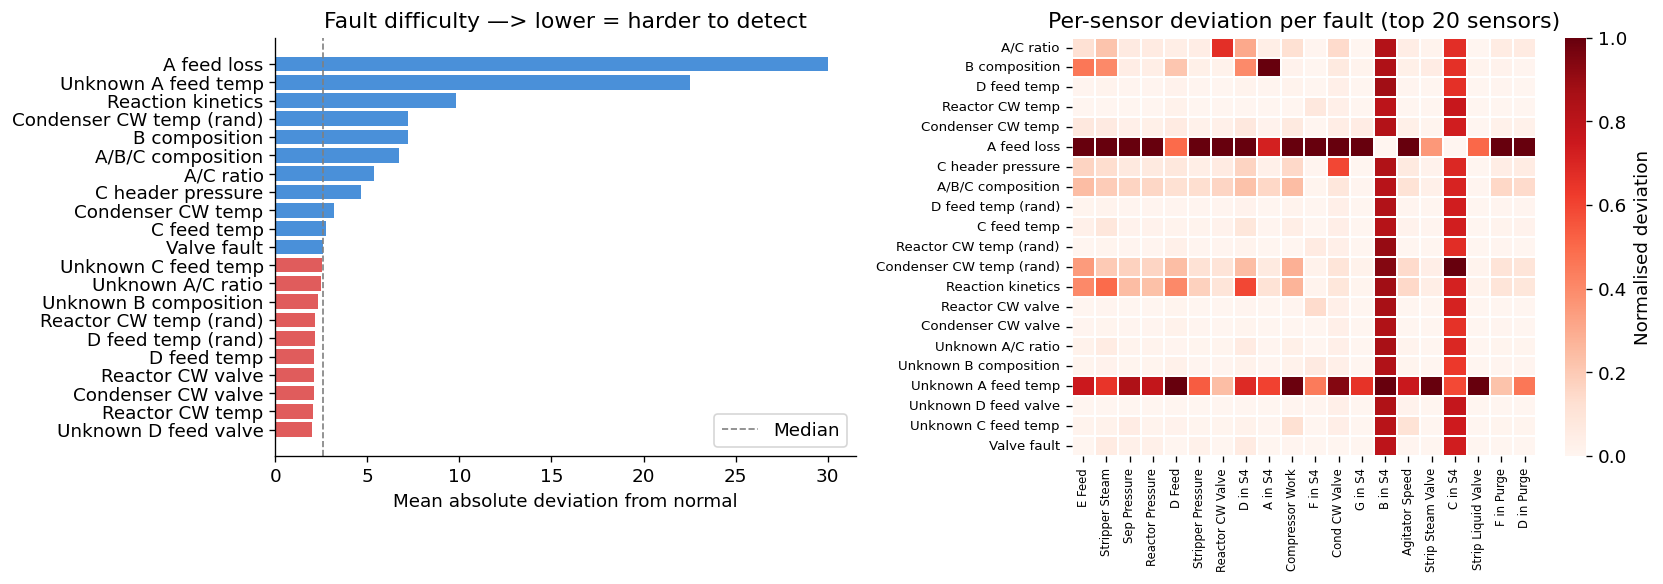

Fault difficulty ranking (hardest → easiest):
  19  Unknown D feed valve          : 1.9728 ← HARD
   4  Reactor CW temp               : 2.0633 ← HARD
  15  Condenser CW valve            : 2.0843 ← HARD
  14  Reactor CW valve              : 2.0931 ← HARD
   3  D feed temp                   : 2.1245 ← HARD
   9  D feed temp (rand)            : 2.1547
  11  Reactor CW temp (rand)        : 2.1610
  17  Unknown B composition         : 2.3344
  16  Unknown A/C ratio             : 2.5055
  20  Unknown C feed temp           : 2.5363
  21  Valve fault                   : 2.5644
  10  C feed temp                   : 2.7351
   5  Condenser CW temp             : 3.1938
   7  C header pressure             : 4.6683
   1  A/C ratio                     : 5.3549
   8  A/B/C composition             : 6.6956
   2  B composition                 : 7.1817
  12  Condenser CW temp (rand)      : 7.2113
  13  Reaction kinetics             : 9.8194
  18  Unknown A feed temp           : 22.5419
   6  A feed loss 

In [25]:
normal_mean = P_normal_df.mean()
fault_dev   = {l: (pd.concat(dfs) - normal_mean).abs().mean()
               for l, dfs in raw_data.items() if l != 0}
dev_df      = pd.DataFrame(fault_dev).T
fault_mean_dev = dev_df.mean(axis=1).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_cols = ['#e05c5c' if d < fault_mean_dev.median() else '#4a90d9'
            for d in fault_mean_dev.values]
axes[0].barh([FAULT_LABELS[l] for l in fault_mean_dev.index],
             fault_mean_dev.values, color=bar_cols, edgecolor='none')
axes[0].axvline(fault_mean_dev.median(), color='gray', linestyle='--', linewidth=1,
                label='Median')
axes[0].set_xlabel('Mean absolute deviation from normal')
axes[0].set_title('Fault difficulty —> lower = harder to detect')
axes[0].legend()

top20 = dev_df.mean().sort_values(ascending=False).head(20).index.tolist()
dev_norm = (dev_df[top20] - dev_df[top20].min()) / \
           (dev_df[top20].max() - dev_df[top20].min() + 1e-9)
sns.heatmap(dev_norm, ax=axes[1], cmap='Reds',
            xticklabels=top20,
            yticklabels=[FAULT_LABELS[l] for l in dev_df.index],
            cbar_kws={'label': 'Normalised deviation'}, linewidths=0.1)
axes[1].set_xticklabels(top20, rotation=90, fontsize=7)
axes[1].set_yticklabels(axes[1].get_yticklabels(), fontsize=8)
axes[1].set_title('Per-sensor deviation per fault (top 20 sensors)')

plt.tight_layout()
plt.savefig('eda_05_fault_difficulty.png', bbox_inches='tight')
plt.show()

print('Fault difficulty ranking (hardest → easiest):')
for l, v in fault_mean_dev.items():
    tag = ' ← HARD' if v < fault_mean_dev.quantile(0.25) else ''
    print(f'  {l:2d}  {FAULT_LABELS[l]:30s}: {v:.4f}{tag}')

### Step 7 — Modality Group Summary

Modality group summary:
             N sensors  Mean variance  Mean abs dev  Mean intra |r|
Modality                                                           
Reactor              9    2112.558105     16.042999           0.206
Separator            5    1214.938965      9.078000           0.227
Stripper             8    1342.094971     11.369000           0.199
Composition         30      44.105999      1.944000           0.305

Suggested initial confidence weights:
  Reactor        : 0.562
  Separator      : 0.183
  Stripper       : 0.253
  Composition    : 0.001


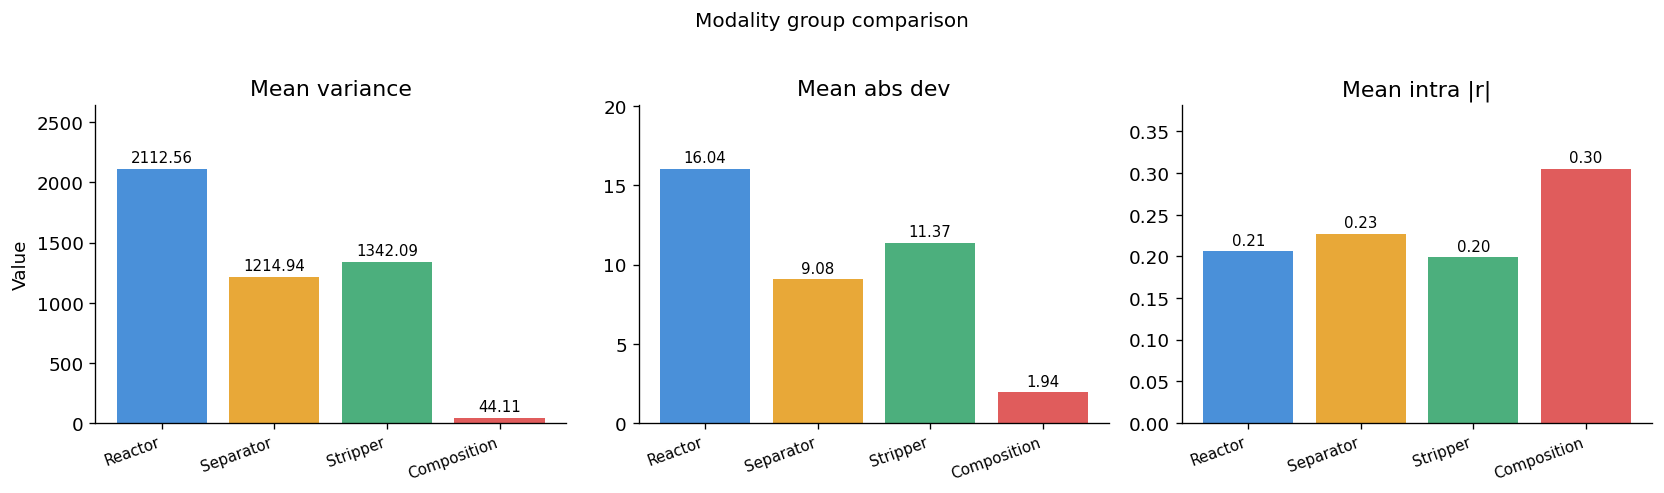

In [26]:
group_stats = []
for grp, indices in MODALITY_GROUPS.items():
    cols     = [SENSOR_NAMES[i] for i in indices]
    grp_data = all_df[cols]
    mean_var  = grp_data.var().mean()
    mean_dev  = (grp_data - grp_data.mean()).abs().mean().mean()
    corr_vals = grp_data.corr().abs().values
    mean_corr = corr_vals[np.triu_indices_from(corr_vals, k=1)].mean() \
                if len(cols) > 1 else 1.0
    group_stats.append({
        'Modality': grp, 'N sensors': len(indices),
        'Mean variance': round(mean_var, 3),
        'Mean abs dev': round(mean_dev, 3),
        'Mean intra |r|': round(mean_corr, 3),
    })

group_stats_df = pd.DataFrame(group_stats).set_index('Modality')
print('Modality group summary:')
print(group_stats_df.to_string())

# Suggested initial confidence weights (used as reference when adding confidence scoring)
raw_score    = group_stats_df['Mean variance'] * group_stats_df['Mean abs dev']
init_weights = (raw_score / raw_score.sum()).round(3)
print('\nSuggested initial confidence weights:')
for grp, w in init_weights.items():
    print(f'  {grp:15s}: {w:.3f}')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics    = ['Mean variance', 'Mean abs dev', 'Mean intra |r|']
grp_cols   = [GROUP_COLORS[g] for g in group_stats_df.index]

for ax, metric in zip(axes, metrics):
    vals = group_stats_df[metric].values
    bars = ax.bar(group_stats_df.index, vals, color=grp_cols, edgecolor='none')
    ax.bar_label(bars, fmt='%.2f', fontsize=9, padding=2)
    ax.set_title(metric)
    ax.set_xticklabels(group_stats_df.index, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, vals.max() * 1.25)

axes[0].set_ylabel('Value')
plt.suptitle('Modality group comparison', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('eda_06_modality_summary.png', bbox_inches='tight')
plt.show()

---
## 4. Preprocessing & DataLoaders

In [27]:
# Scale each modality independently (different physical units per group)
scalers        = {}
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()   # Initialize X_val_scaled
X_test_scaled  = X_test.copy()
N_tr, T, F     = X_train.shape
N_te           = X_test.shape[0]

for grp, indices in MODALITY_GROUPS.items():
    sc = StandardScaler()
    X_train_scaled[:, :, indices] = sc.fit_transform(
        X_train[:, :, indices].reshape(-1, len(indices))
    ).reshape(N_tr, T, len(indices))
    X_val_scaled[:, :, indices] = sc.transform(  # Scale X_val_scaled
        X_val[:, :, indices].reshape(-1, len(indices))
    ).reshape(X_val.shape[0], T, len(indices))
    X_test_scaled[:, :, indices] = sc.transform(
        X_test[:, :, indices].reshape(-1, len(indices))
    ).reshape(N_te, T, len(indices))
    scalers[grp] = sc

print('Per-group scaling done.')
print(f'Train mean ~0: {X_train_scaled.mean():.4f}  |  std ~1: {X_train_scaled.std():.4f}')

Per-group scaling done.
Train mean ~0: 0.0000  |  std ~1: 1.0000


In [28]:
class TEPDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]


train_loader = DataLoader(TEPDataset(X_train_scaled, y_train),
                          batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(TEPDataset(X_val_scaled,   y_val),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TEPDataset(X_test_scaled,  y_test),
                          batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print('Batch shape:', xb.shape, '| Labels:', yb.shape)

Batch shape: torch.Size([64, 80, 52]) | Labels: torch.Size([64])


---
## 5. Model Architecture

```
Input (B, 80, 52)
       │
       ├── Reactor    (B, 80,  9) → PatchTSTEncoder → (B, 128)
       ├── Separator  (B, 80,  5) → PatchTSTEncoder → (B, 128)
       ├── Stripper   (B, 80,  8) → PatchTSTEncoder → (B, 128)
       └── Composition(B, 80, 30) → PatchTSTEncoder → (B, 128)
                                           │
                                Concat → (B, 512)
                                           │
                               Fusion MLP → (B, 128)
                                           │
                              Classifier → (B, 22)
```

In [29]:
class PatchTSTEncoder(nn.Module):
    """
    Single-modality PatchTST encoder.
    Input : (B, T, input_dim)
    Output: (B, d_model)
    """
    def __init__(self, input_dim, patch_len=PATCH_LEN, seq_len=WINDOW_SIZE,
                 d_model=D_MODEL, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
                 dropout=DROPOUT):
        super().__init__()
        assert seq_len % patch_len == 0
        self.patch_len   = patch_len
        self.num_patches = seq_len // patch_len

        self.patch_embed = nn.Linear(patch_len * input_dim, d_model)
        self.pos_enc     = nn.Parameter(torch.zeros(1, self.num_patches, d_model))
        nn.init.trunc_normal_(self.pos_enc, std=0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads,
            dim_feedforward=d_model * 4, dropout=dropout,
            batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(
            enc_layer, num_layers=num_layers, norm=nn.LayerNorm(d_model)
        )

    def forward(self, x):
        B, T, F = x.shape
        x = x.reshape(B, self.num_patches, self.patch_len * F)
        x = self.patch_embed(x) + self.pos_enc
        x = self.transformer(x)
        return x.mean(dim=1)   # global average pool → (B, d_model)


class MultimodalPatchTST(nn.Module):
    """
    Multimodal PatchTST — equal-weight fusion baseline.
    No confidence scoring (that is the next model).
    """
    def __init__(self, modality_dims=MODALITY_DIMS, d_model=D_MODEL,
                 num_classes=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()
        self.modality_groups = MODALITY_GROUPS
        n_mod = len(modality_dims)

        self.encoders = nn.ModuleDict({
            grp: PatchTSTEncoder(input_dim=dim)
            for grp, dim in modality_dims.items()
        })

        self.fusion = nn.Sequential(
            nn.Linear(n_mod * d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, x):
        embeddings = []
        for grp, indices in self.modality_groups.items():
            z = self.encoders[grp](x[:, :, indices])
            embeddings.append(z)
        fused = self.fusion(torch.cat(embeddings, dim=-1))
        return self.classifier(fused)


model = MultimodalPatchTST().to(device)

for grp, enc in model.encoders.items():
    n = sum(p.numel() for p in enc.parameters())
    print(f'  {grp:15s} encoder: {n:>8,} params')
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n  Total trainable params: {total:,}')

  Reactor         encoder:  605,696 params
  Separator       encoder:  601,600 params
  Stripper        encoder:  604,672 params
  Composition     encoder:  627,200 params

  Total trainable params: 2,507,926


---
## 6. Training

In [30]:
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw = torch.tensor(cw, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == yb).sum().item()
        total      += len(yb)
    return total_loss / len(loader), correct / total


def eval_epoch(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for Xb, yb in loader:
            out = model(Xb.to(device))
            correct += (out.argmax(1).cpu() == yb).sum().item()
            total   += len(yb)
    return correct / total


print(f'{"Epoch":>6}  {"Train Loss":>10}  {"Train Acc":>10}  {"Val Acc":>8}  {"LR":>9}')
print('-' * 58)

best_val_acc = 0.0
best_state   = None
history      = {'train_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader)
    val_acc         = eval_epoch(model, val_loader)   # FIX: use val, not test
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    lr_now = scheduler.get_last_lr()[0]
    print(f'{epoch:>6}  {tr_loss:>10.4f}  {tr_acc:>9.1%}  {val_acc:>7.1%}  {lr_now:.3e}')

print(f'\nBest validation accuracy: {best_val_acc:.1%}')

 Epoch  Train Loss   Train Acc   Val Acc         LR
----------------------------------------------------------
     1      1.2599      72.7%    71.9%  9.938e-04
     2      0.5147      96.0%    73.2%  9.755e-04
     3      0.4273      98.5%    73.3%  9.455e-04
     4      0.4054      98.9%    73.0%  9.045e-04
     5      0.3880      99.3%    75.8%  8.536e-04
     6      0.3800      99.4%    75.6%  7.939e-04
     7      0.3736      99.5%    75.8%  7.270e-04
     8      0.3725      99.4%    75.2%  6.545e-04
     9      0.3710      99.5%    73.9%  5.782e-04
    10      0.3705      99.4%    74.2%  5.000e-04
    11      0.3694      99.6%    74.2%  4.218e-04
    12      0.3694      99.5%    74.7%  3.455e-04
    13      0.3689      99.5%    74.9%  2.730e-04
    14      0.3682      99.5%    75.0%  2.061e-04
    15      0.3680      99.6%    74.9%  1.464e-04
    16      0.3678      99.5%    75.3%  9.549e-05
    17      0.3675      99.5%    75.0%  5.450e-05
    18      0.3682      99.4%    75.2% 

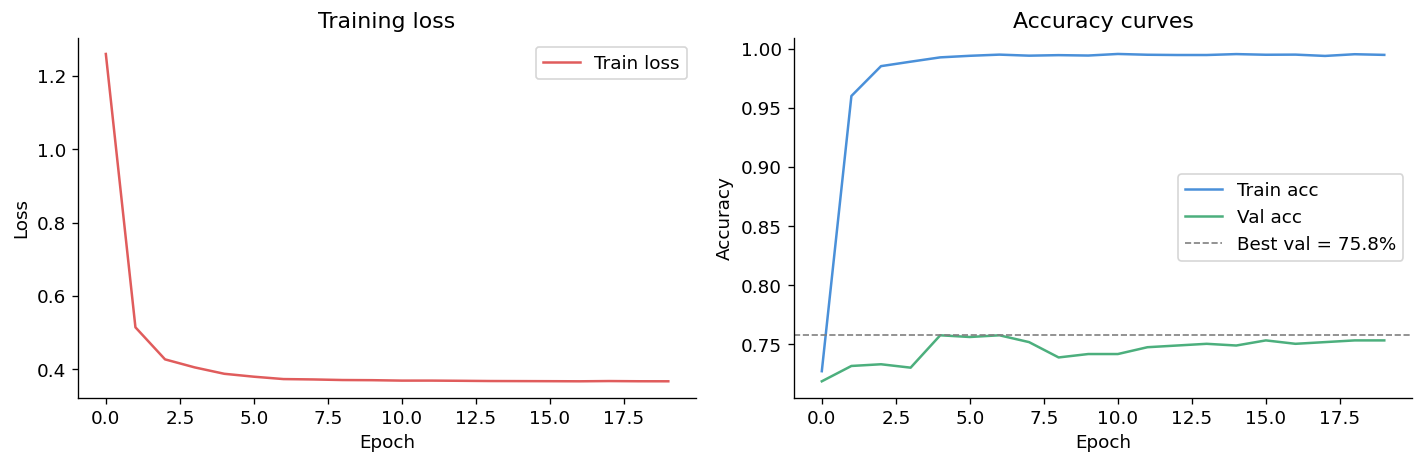

In [31]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], color='#e05c5c', label='Train loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training loss'); axes[0].legend()

axes[1].plot(history['train_acc'], color='#4a90d9', label='Train acc')
axes[1].plot(history['val_acc'],   color='#4caf7d', label='Val acc')
axes[1].axhline(best_val_acc, color='gray', linestyle='--', linewidth=1,
                label=f'Best val = {best_val_acc:.1%}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy curves'); axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight')
plt.show()

---
## 7. Evaluation

In [32]:
model.load_state_dict(best_state)
model.to(device).eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        out = model(Xb.to(device))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(yb.numpy())

present = sorted(set(all_labels))
names   = ['Normal'] + [f'Fault {i}' for i in range(1, 22)]

print(f'Test Accuracy: {accuracy_score(all_labels, all_preds):.4f}\n')
print(classification_report(
    all_labels, all_preds,
    labels=present, target_names=[names[i] for i in present]
))

Test Accuracy: 0.8528

              precision    recall  f1-score   support

     Fault 1       1.00      1.00      1.00        33
     Fault 2       1.00      1.00      1.00        33
     Fault 3       0.00      0.00      0.00        33
     Fault 4       1.00      1.00      1.00        33
     Fault 5       1.00      1.00      1.00        33
     Fault 6       0.87      1.00      0.93        33
     Fault 7       1.00      1.00      1.00        33
     Fault 8       1.00      1.00      1.00        33
     Fault 9       0.41      0.42      0.42        33
    Fault 10       0.85      1.00      0.92        33
    Fault 11       1.00      1.00      1.00        33
    Fault 12       0.85      1.00      0.92        33
    Fault 13       0.79      0.91      0.85        33
    Fault 14       0.92      1.00      0.96        33
    Fault 15       0.86      0.18      0.30        33
    Fault 16       0.42      0.45      0.43        33
    Fault 17       1.00      1.00      1.00        33
    

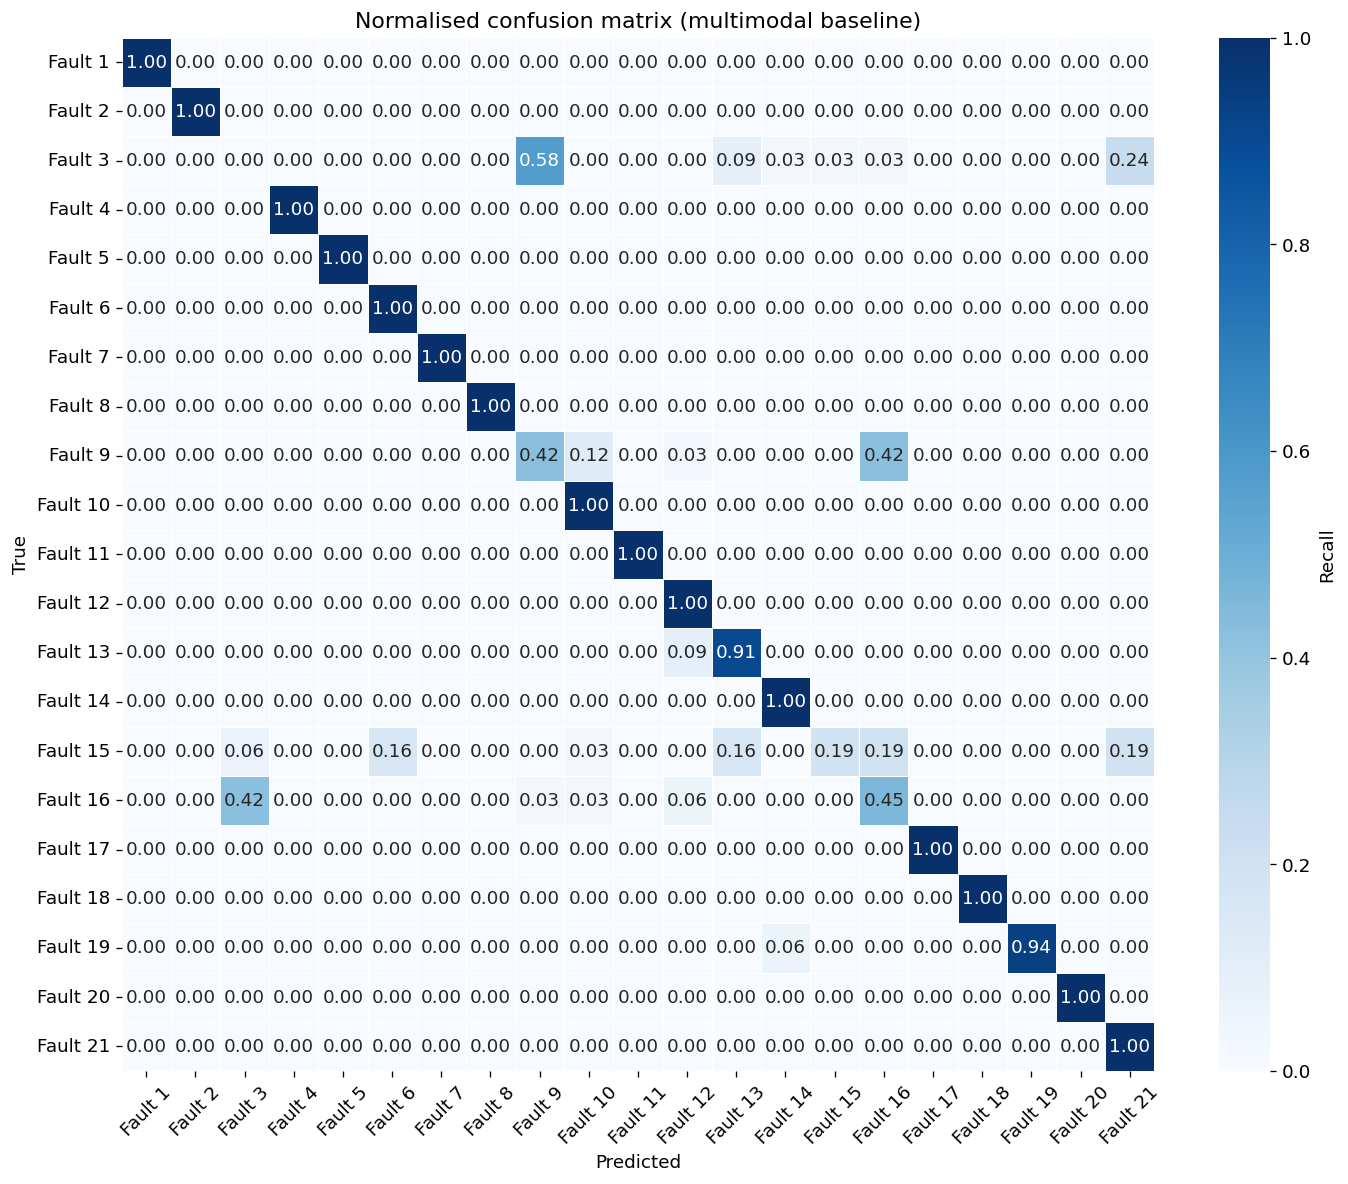

In [33]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds, labels=present)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_norm, ax=ax, cmap='Blues', annot=True, fmt='.2f',
            xticklabels=[names[i] for i in present],
            yticklabels=[names[i] for i in present],
            cbar_kws={'label': 'Recall'}, linewidths=0.3)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Normalised confusion matrix (multimodal baseline)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

---
## 8. Per-Modality Embedding Analysis
Proxy for how much each modality contributes under equal weighting.

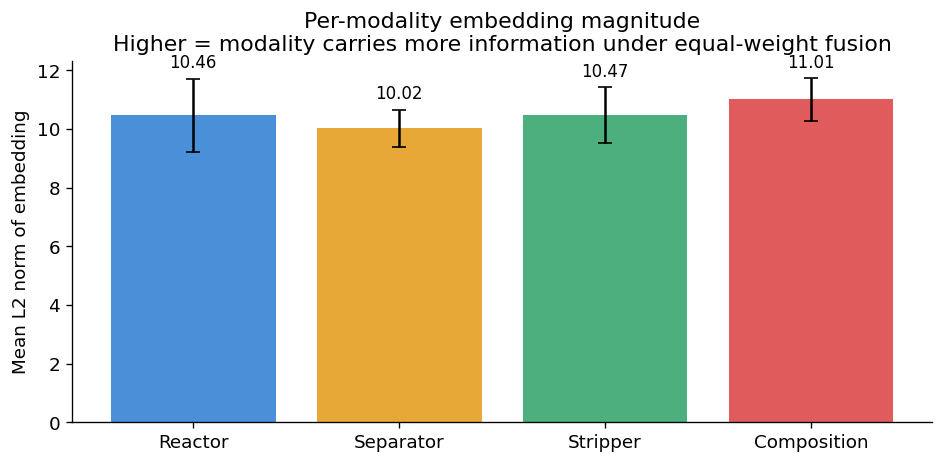

Modality norms (mean ± std):
  Reactor        : 10.462 ± 1.250
  Separator      : 10.019 ± 0.636
  Stripper       : 10.470 ± 0.944
  Composition    : 11.005 ± 0.728

This plot feeds directly into your confidence-aware model.
Modalities with low norm under equal weighting are candidates for lower confidence.


In [34]:
model.eval()
modality_norms = {grp: [] for grp in MODALITY_GROUPS}

with torch.no_grad():
    for Xb, _ in test_loader:
        Xb = Xb.to(device)
        for grp, indices in MODALITY_GROUPS.items():
            z = model.encoders[grp](Xb[:, :, indices])
            modality_norms[grp].extend(torch.norm(z, dim=-1).cpu().tolist())

fig, ax = plt.subplots(figsize=(8, 4))
means = [np.mean(modality_norms[g]) for g in MODALITY_GROUPS]
stds  = [np.std(modality_norms[g])  for g in MODALITY_GROUPS]
bars  = ax.bar(MODALITY_GROUPS.keys(), means, yerr=stds,
               color=[GROUP_COLORS[g] for g in MODALITY_GROUPS],
               edgecolor='none', capsize=4)
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=10)
ax.set_ylabel('Mean L2 norm of embedding')
ax.set_title('Per-modality embedding magnitude\n'
             'Higher = modality carries more information under equal-weight fusion')
plt.tight_layout()
plt.savefig('modality_embedding_norms.png', bbox_inches='tight')
plt.show()

print('Modality norms (mean ± std):')
for grp in MODALITY_GROUPS:
    print(f'  {grp:15s}: {np.mean(modality_norms[grp]):.3f} ± {np.std(modality_norms[grp]):.3f}')

print('\nThis plot feeds directly into your confidence-aware model.')
print('Modalities with low norm under equal weighting are candidates for lower confidence.')

---
## 9. Save

In [35]:
torch.save({
    'model_state_dict': best_state,
    'scalers': scalers,
    'config': {
        'modality_groups': MODALITY_GROUPS,
        'modality_dims':   MODALITY_DIMS,
        'patch_len':       PATCH_LEN,
        'd_model':         D_MODEL,
        'num_heads':       NUM_HEADS,
        'num_layers':      NUM_LAYERS,
        'window_size':     WINDOW_SIZE,
        'num_classes':     NUM_CLASSES,
    },
    'history': history,
    'best_val_acc': best_val_acc,
}, 'multimodal_patchtst_baseline.pt')

print('Saved → multimodal_patchtst_baseline.pt')
print(f'Best val accuracy: {best_val_acc:.1%}')
print('\nNext step: add confidence-aware modality weighting and compare against this baseline.')

Saved → multimodal_patchtst_baseline.pt
Best val accuracy: 75.8%

Next step: add confidence-aware modality weighting and compare against this baseline.


---
## 10. Confidence-Aware Multimodal PatchTST

Extends the baseline with a **confidence head** per modality.
Instead of equal-weight concatenation, each modality gets a scalar
confidence score. The final representation is a **weighted sum** of
modality embeddings where weights = softmax of confidence logits.

```
Input (B, 80, 52)
       |
       +-- Reactor     --> PatchTSTEncoder --> z_r  (B,128)  --+
       +-- Separator   --> PatchTSTEncoder --> z_s  (B,128)  --| confidence
       +-- Stripper    --> PatchTSTEncoder --> z_st (B,128)  --| heads
       +-- Composition --> PatchTSTEncoder --> z_c  (B,128)  --+
                                |                   |
                          embeddings         scores w_i in [0,1]
                                |                   |
                         weighted sum: sum(w_i * z_i) --> (B,128)
                                |
                         Classifier --> (B, 22)
```


In [37]:
class ConfidenceAwareMultimodalPatchTST(nn.Module):
    """
    Confidence-Aware Multimodal PatchTST — v3 (fixed).

    Key fixes:
      1. Weighted CONCAT + fusion MLP (same capacity as baseline, but gated)
         instead of weighted SUM — the weighted sum was collapsing 4×128=512 dims
         down to 128, losing most of the information.
      2. Sigmoid gates (independent per modality, no zero-sum softmax competition)
      3. Statistical confidence (variance-based) blended with learned score
      4. Auxiliary classifier per encoder (gives confidence heads a real signal)
    """

    def __init__(self, modality_dims=MODALITY_DIMS, d_model=D_MODEL,
                 num_classes=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()
        self.modality_groups = MODALITY_GROUPS
        n_mod = len(modality_dims)

        # One PatchTST encoder per modality (same as baseline)
        self.encoders = nn.ModuleDict({
            grp: PatchTSTEncoder(input_dim=dim)
            for grp, dim in modality_dims.items()
        })

        # Learned confidence head per modality: embedding → scalar gate
        self.confidence_heads = nn.ModuleDict({
            grp: nn.Sequential(
                nn.Linear(d_model, d_model // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(d_model // 2, 1),
            )
            for grp in modality_dims
        })

        # Auxiliary classifier per encoder (same signal that confidence learns from)
        self.aux_classifiers = nn.ModuleDict({
            grp: nn.Linear(d_model, num_classes)
            for grp in modality_dims
        })

        # FIX: Fusion MLP — same as baseline (n_mod * d_model → d_model)
        # This preserves the full 512-dim information before compressing,
        # just like the baseline does, but with adaptive gating applied first.
        self.fusion = nn.Sequential(
            nn.Linear(n_mod * d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # Main classifier on fused representation
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def compute_stat_confidence(self, x_grp):
        """
        Statistical confidence from input variance.
        High variance = sensor is active = more informative = higher confidence.
        Returns a (B, 1) score.
        """
        var   = x_grp.var(dim=1).mean(dim=-1, keepdim=True)  # (B, 1)
        score = torch.sigmoid(var - var.mean())               # centred sigmoid
        return score

    def forward(self, x, return_confidences=False, return_aux=False):
        # x: (B, 80, 52)
        B = x.shape[0]
        embeddings = {}
        gates      = {}
        aux_logits = {}

        for grp, indices in self.modality_groups.items():
            x_grp = x[:, :, indices]
            z     = self.encoders[grp](x_grp)                # (B, d_model)

            # Confidence = learned score + statistical score (blended)
            learned_score = self.confidence_heads[grp](z)    # (B, 1)
            stat_score    = self.compute_stat_confidence(x_grp)
            gate          = torch.sigmoid(learned_score + stat_score)

            embeddings[grp] = z
            gates[grp]      = gate                           # (B, 1)
            aux_logits[grp] = self.aux_classifiers[grp](z)  # (B, num_classes)

        # Stack gates: (B, n_modalities) — normalise so they sum to 1
        gate_stack = torch.cat(list(gates.values()), dim=-1)    # (B, n_mod)
        gate_norm  = gate_stack / (gate_stack.sum(dim=-1, keepdim=True) + 1e-9)

        # FIX: Weighted CONCAT, not weighted SUM
        # Scale each embedding by its gate, then concatenate → full 512-dim repr
        # Baseline does: concat(z1,z2,z3,z4) → MLP
        # CA  does:      concat(w1*z1, w2*z2, w3*z3, w4*z4) → same MLP
        emb_stack     = torch.stack(list(embeddings.values()), dim=1)  # (B, n_mod, d_model)
        weighted_embs = gate_norm.unsqueeze(-1) * emb_stack            # (B, n_mod, d_model)
        fused_input   = weighted_embs.reshape(B, -1)                   # (B, n_mod * d_model)
        fused         = self.fusion(fused_input)                       # (B, d_model)

        out = self.classifier(fused)

        if return_aux:
            return out, gate_norm, aux_logits
        if return_confidences:
            return out, gate_norm
        return out


# =============================================================================
# TRAINING UTILITIES
# =============================================================================

def ca_train_epoch(model, loader, optimizer, criterion):
    """
    Training step with auxiliary encoder losses.
    Each encoder independently predicts the fault label (weighted 0.2).
    This gives confidence heads a meaningful gradient signal.
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()

        out, gates, aux_logits = model(Xb, return_aux=True)

        # Main classification loss
        cls_loss = criterion(out, yb)

        # Auxiliary loss — each encoder independently predicts fault
        aux_loss = sum(
            criterion(aux_out, yb) * 0.2
            for aux_out in aux_logits.values()
        )

        loss = cls_loss + aux_loss
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += cls_loss.item()
        correct    += (out.argmax(1) == yb).sum().item()
        total      += len(yb)

    return total_loss / len(loader), correct / total


def eval_model(model, loader):
    """Return (preds, labels) arrays."""
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            out = model(Xb.to(device))
            if isinstance(out, tuple):
                out = out[0]
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    return np.array(preds), np.array(labels)


def acc(model, loader):
    p, l = eval_model(model, loader)
    return accuracy_score(l, p)


def check_gate_collapse(model, loader):
    """Print gate statistics — detects if gates collapsed to uniform."""
    model.eval()
    ws = []
    with torch.no_grad():
        for Xb, _ in loader:
            _, w = model(Xb.to(device), return_confidences=True)
            ws.append(w.cpu().numpy())
    ws       = np.concatenate(ws)
    mean_std = ws.std(axis=1).mean()
    print(f'\n  Gate std (mean across samples): {mean_std:.4f}  '
          f'{"OK" if mean_std > 0.02 else "WARNING: near-uniform"}')
    for i, grp in enumerate(MODALITY_GROUPS.keys()):
        print(f'    {grp:15s}: {ws[:,i].mean():.4f} \u00b1 {ws[:,i].std():.4f}')
    return ws


In [38]:
# =============================================================================
# MODEL INITIALIZATION + WEIGHT TRANSFER
# =============================================================================

ca_model = ConfidenceAwareMultimodalPatchTST().to(device)

# Copy pretrained encoder weights from baseline
baseline_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
ca_state = ca_model.state_dict()

loaded = 0
for key in ca_state:
    if key.startswith('encoders.') and key in baseline_state:
        ca_state[key] = baseline_state[key]
        loaded += 1

ca_model.load_state_dict(ca_state)
print(f'\n  Copied {loaded} encoder weight tensors from baseline.')


# =============================================================================
# PARAMETER COUNT
# =============================================================================

for grp, enc in ca_model.encoders.items():
    n = sum(p.numel() for p in enc.parameters())
    print(f'  {grp:15s} encoder:         {n:>8,} params')

for grp, head in ca_model.confidence_heads.items():
    n = sum(p.numel() for p in head.parameters())
    print(f'  {grp:15s} confidence head: {n:>8,} params')

for grp, aux in ca_model.aux_classifiers.items():
    n = sum(p.numel() for p in aux.parameters())
    print(f'  {grp:15s} aux classifier:  {n:>8,} params')

total_ca = sum(p.numel() for p in ca_model.parameters() if p.requires_grad)
total_bl = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'\n  Baseline total:              {total_bl:>8,} params')
print(f'  Confidence-aware total:      {total_ca:>8,} params')
print(f'  Extra (conf + aux heads):    {total_ca - total_bl:>8,} params')


# =============================================================================
# LOSS FUNCTION (IMPROVED)
# =============================================================================

ca_criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.05)  # FIX: match baseline smoothing


# =============================================================================
# PHASE 1 — PARTIAL FREEZE (BETTER STRATEGY)
# =============================================================================

print('\n' + '-' * 65)
print('Phase 1 — Partial freeze (15 epochs)')
print('-' * 65)

for name, param in ca_model.named_parameters():
    if "encoders" in name:
        param.requires_grad = False
    else:
        param.requires_grad = True

trainable_p1 = sum(p.numel() for p in ca_model.parameters() if p.requires_grad)
print(f'  Trainable params this phase: {trainable_p1:,}')


# Better LR
p1_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, ca_model.parameters()),
    lr=5e-4,  # slightly higher for faster warm-up
    weight_decay=1e-4
)

p1_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(p1_optimizer, T_max=15)

ca_best_acc, ca_best_state = 0.0, None

print(f'\n  {"Ep":>4}  {"Loss":>9}  {"Train Acc":>10}  {"Val Acc":>9}  {"LR":>9}')
print('  ' + '-' * 50)


for epoch in range(1, 16):

    tl, ta = ca_train_epoch(ca_model, train_loader, p1_optimizer, ca_criterion)

    # FIX: USE VALIDATION, NOT TEST
    va = acc(ca_model, val_loader)

    p1_scheduler.step()

    if va > ca_best_acc:
        ca_best_acc = va
        ca_best_state = {k: v.cpu().clone() for k, v in ca_model.state_dict().items()}

    lr_now = p1_scheduler.get_last_lr()[0]
    marker = ' <-- best' if va == ca_best_acc else ''

    print(f'  {epoch:>4}  {tl:>9.4f}  {ta:>9.1%}  {va:>8.1%}  {lr_now:.3e}{marker}')


print(f'\n  Phase 1 best val accuracy: {ca_best_acc:.4f}')


# Optional: check collapse on validation instead of test
check_gate_collapse(ca_model, val_loader)


# =============================================================================
# PHASE 2 — FULL FINE-TUNING
# =============================================================================

print('\n' + '-' * 65)
print('Phase 2 — Full fine-tuning (25 epochs)')
print('-' * 65)


# LOAD BEST MODEL FROM PHASE 1
ca_model.load_state_dict(ca_best_state)
print("  Loaded best Phase 1 model")


# Unfreeze all
for param in ca_model.parameters():
    param.requires_grad = True


# Better LR
p2_optimizer = torch.optim.AdamW(
    ca_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

p2_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(p2_optimizer, T_max=35)  # extended


print(f'\n  {"Ep":>4}  {"Loss":>9}  {"Train Acc":>10}  {"Val Acc":>9}  {"LR":>9}')
print('  ' + '-' * 50)


for epoch in range(1, 36):  # extended from 25 to 35 epochs

    tl, ta = ca_train_epoch(ca_model, train_loader, p2_optimizer, ca_criterion)

    # VALIDATION (correct)
    va = acc(ca_model, val_loader)

    p2_scheduler.step()

    if va > ca_best_acc:
        ca_best_acc = va
        ca_best_state = {k: v.cpu().clone() for k, v in ca_model.state_dict().items()}

    lr_now = p2_scheduler.get_last_lr()[0]
    marker = ' <-- best' if va == ca_best_acc else ''

    print(f'  {epoch:>4}  {tl:>9.4f}  {ta:>9.1%}  {va:>8.1%}  {lr_now:.3e}{marker}')


print(f'\n  Phase 2 best val accuracy: {ca_best_acc:.4f}')





  Copied 164 encoder weight tensors from baseline.
  Reactor         encoder:          605,696 params
  Separator       encoder:          601,600 params
  Stripper        encoder:          604,672 params
  Composition     encoder:          627,200 params
  Reactor         confidence head:    8,321 params
  Separator       confidence head:    8,321 params
  Stripper        confidence head:    8,321 params
  Composition     confidence head:    8,321 params
  Reactor         aux classifier:     2,838 params
  Separator       aux classifier:     2,838 params
  Stripper        aux classifier:     2,838 params
  Composition     aux classifier:     2,838 params

  Baseline total:              2,507,926 params
  Confidence-aware total:      2,552,562 params
  Extra (conf + aux heads):      44,636 params

-----------------------------------------------------------------
Phase 1 — Partial freeze (15 epochs)
-----------------------------------------------------------------
  Trainable params thi

In [39]:
ca_model.load_state_dict(ca_best_state)
ca_model.eval()

ca_preds, ca_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        out, _ = ca_model(X_batch.to(device), return_confidences=True)
        ca_preds.extend(out.argmax(1).cpu().numpy())
        ca_labels.extend(y_batch.numpy())

ca_preds  = np.array(ca_preds)
ca_labels = np.array(ca_labels)

# Use all_labels and all_preds from baseline evaluation
bl_labels = np.array(all_labels)
bl_preds  = np.array(all_preds)

ca_acc = accuracy_score(ca_labels, ca_preds)
bl_acc = accuracy_score(bl_labels, bl_preds)

print('Baseline accuracy:         ', round(bl_acc, 4))
print('Confidence-aware accuracy: ', round(ca_acc, 4))
print('Improvement:               ', round((ca_acc - bl_acc) * 100, 2), '%')
print()

present_labels = sorted(np.unique(ca_labels))
names_map = {i: FAULT_LABELS[i] for i in range(NUM_CLASSES)}

# Dynamically create target_names based on present_labels
display_target_names = [names_map[i] for i in present_labels]

print(classification_report(ca_labels, ca_preds,
      labels=present_labels, target_names=display_target_names))

Baseline accuracy:          0.8528
Confidence-aware accuracy:  0.847
Improvement:                -0.58 %

                          precision    recall  f1-score   support

               A/C ratio       0.97      1.00      0.99        33
           B composition       1.00      1.00      1.00        33
             D feed temp       0.10      0.06      0.07        33
         Reactor CW temp       1.00      1.00      1.00        33
       Condenser CW temp       1.00      1.00      1.00        33
             A feed loss       0.97      1.00      0.99        33
       C header pressure       1.00      1.00      1.00        33
       A/B/C composition       0.94      1.00      0.97        33
      D feed temp (rand)       0.44      0.33      0.38        33
             C feed temp       0.73      1.00      0.85        33
  Reactor CW temp (rand)       1.00      1.00      1.00        33
Condenser CW temp (rand)       0.94      1.00      0.97        33
       Reaction kinetics       0.92

## Confidence Weight Analysis
How much does each modality get trusted on average? Does it vary across fault types?

In [40]:
# collect gate weights and true labels from the test set
ca_model.load_state_dict(ca_best_state)
ca_model.eval()

all_gates  = []   # (N, 4)
gate_labels = []  # (N,)

with torch.no_grad():
    for Xb, yb in test_loader:
        _, w = ca_model(Xb.to(device), return_confidences=True)
        all_gates.append(w.cpu().numpy())
        gate_labels.extend(yb.numpy())

all_gates   = np.concatenate(all_gates, axis=0)   # (N, 4)
gate_labels = np.array(gate_labels)                # (N,)

modality_names = list(MODALITY_GROUPS.keys())

print('Overall mean gate weights (across all test samples):')
for i, grp in enumerate(modality_names):
    print(f'  {grp:15s}: {all_gates[:, i].mean():.4f} +/- {all_gates[:, i].std():.4f}')

mean_std = all_gates.std(axis=1).mean()
print(f'\nMean gate std per sample: {mean_std:.4f}')
if mean_std < 0.02:
    print('WARNING: gates are near-uniform — confidence weighting may not have learned much.')
else:
    print('Gates show meaningful spread — confidence weighting is working.')


Overall mean gate weights (across all test samples):
  Reactor        : 0.2887 +/- 0.1744
  Separator      : 0.1678 +/- 0.0862
  Stripper       : 0.2022 +/- 0.1486
  Composition    : 0.3413 +/- 0.1603

Mean gate std per sample: 0.1522
Gates show meaningful spread — confidence weighting is working.


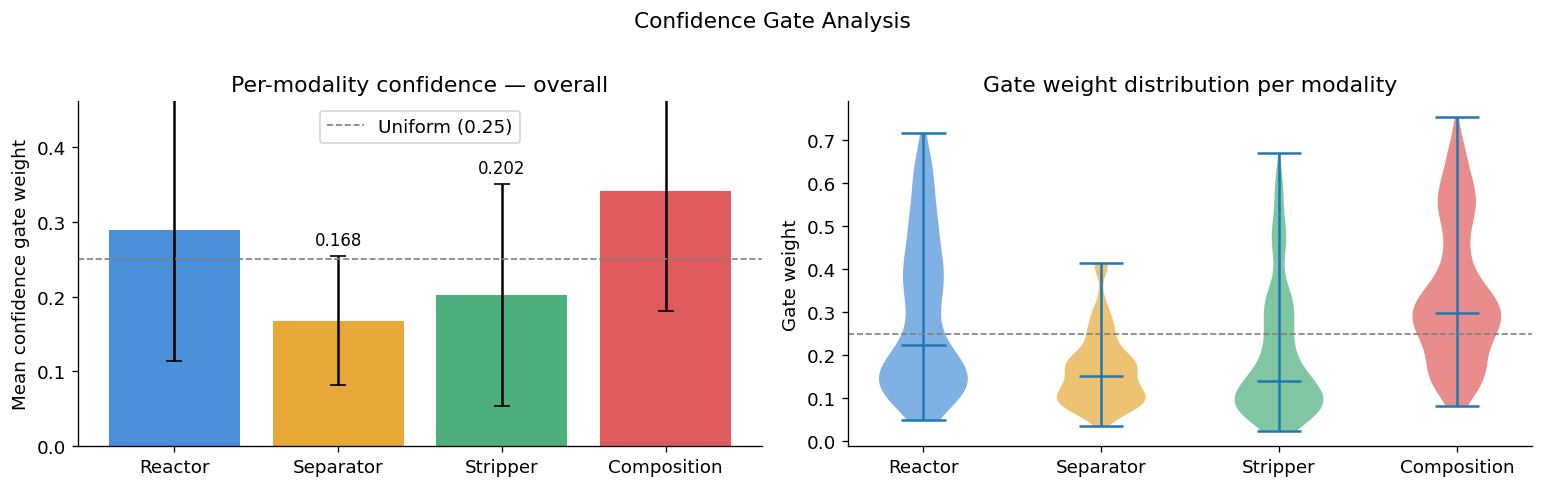

In [41]:
# plot 1: overall mean gate weights per modality
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

means = [all_gates[:, i].mean() for i in range(4)]
stds  = [all_gates[:, i].std()  for i in range(4)]
cols  = [GROUP_COLORS[g] for g in modality_names]

bars = axes[0].bar(modality_names, means, yerr=stds, color=cols,
                   edgecolor='none', capsize=5)
axes[0].bar_label(bars, fmt='%.3f', padding=4, fontsize=10)
axes[0].axhline(0.25, color='gray', linestyle='--', linewidth=1,
                label='Uniform (0.25)')
axes[0].set_ylabel('Mean confidence gate weight')
axes[0].set_title('Per-modality confidence — overall')
axes[0].set_ylim(0, max(means) * 1.35)
axes[0].legend()

# plot 2: gate weight distributions (violin)
parts = axes[1].violinplot(
    [all_gates[:, i] for i in range(4)],
    positions=range(4), showmedians=True
)
for pc, col in zip(parts['bodies'], cols):
    pc.set_facecolor(col)
    pc.set_alpha(0.7)
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(modality_names)
axes[1].axhline(0.25, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylabel('Gate weight')
axes[1].set_title('Gate weight distribution per modality')

plt.suptitle('Confidence Gate Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('confidence_weights_overall.png', bbox_inches='tight')
plt.show()


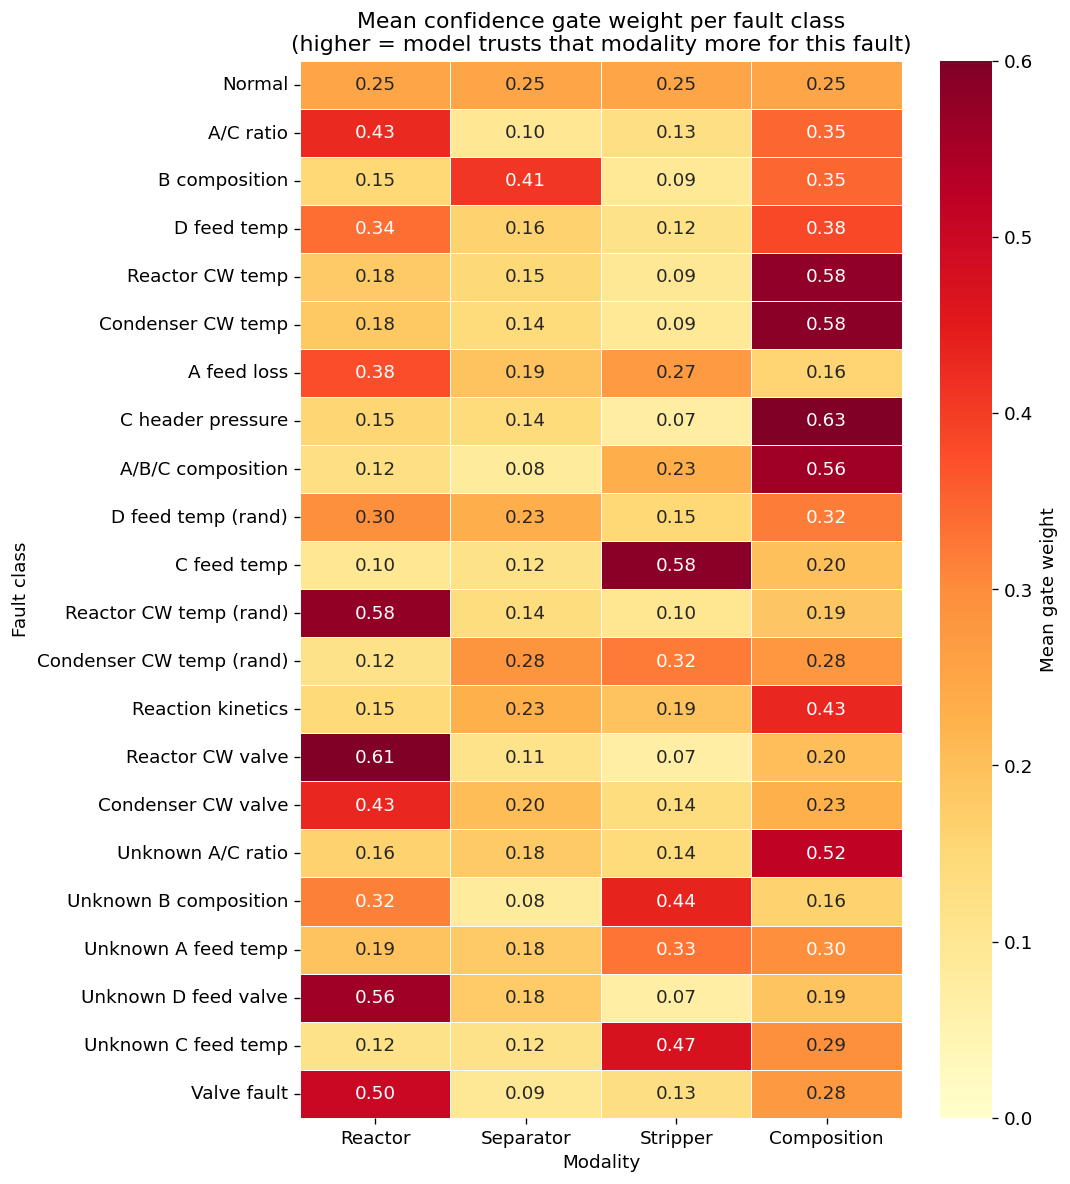

Top modality per fault class:
   0  Normal                          ->  Reactor         (0.250)
   1  A/C ratio                       ->  Reactor         (0.428)
   2  B composition                   ->  Separator       (0.410)
   3  D feed temp                     ->  Composition     (0.382)
   4  Reactor CW temp                 ->  Composition     (0.577)
   5  Condenser CW temp               ->  Composition     (0.584)
   6  A feed loss                     ->  Reactor         (0.375)
   7  C header pressure               ->  Composition     (0.631)
   8  A/B/C composition               ->  Composition     (0.561)
   9  D feed temp (rand)              ->  Composition     (0.321)
  10  C feed temp                     ->  Stripper        (0.585)
  11  Reactor CW temp (rand)          ->  Reactor         (0.575)
  12  Condenser CW temp (rand)        ->  Stripper        (0.322)
  13  Reaction kinetics               ->  Composition     (0.430)
  14  Reactor CW valve                ->  Reac

In [42]:
# plot 3: mean gate weight per fault class — heatmap
# shows which modality the model leans on for each fault type

per_class_gates = np.zeros((NUM_CLASSES, 4))

for cls in range(NUM_CLASSES):
    mask = gate_labels == cls
    if mask.sum() > 0:
        per_class_gates[cls] = all_gates[mask].mean(axis=0)
    else:
        per_class_gates[cls] = 0.25   # fill uniform if class not in test set

per_class_df = pd.DataFrame(
    per_class_gates,
    index=[FAULT_LABELS[i] for i in range(NUM_CLASSES)],
    columns=modality_names
)

fig, ax = plt.subplots(figsize=(9, 10))
sns.heatmap(per_class_df, ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
            vmin=0.0, vmax=0.6,
            cbar_kws={'label': 'Mean gate weight'},
            linewidths=0.3)
ax.set_title('Mean confidence gate weight per fault class\n'
             '(higher = model trusts that modality more for this fault)')
ax.set_xlabel('Modality')
ax.set_ylabel('Fault class')
plt.tight_layout()
plt.savefig('confidence_weights_per_class.png', bbox_inches='tight')
plt.show()

print('Top modality per fault class:')
for cls in range(NUM_CLASSES):
    top_mod = per_class_df.loc[FAULT_LABELS[cls]].idxmax()
    top_w   = per_class_df.loc[FAULT_LABELS[cls]].max()
    print(f'  {cls:2d}  {FAULT_LABELS[cls]:30s}  ->  {top_mod:15s} ({top_w:.3f})')


In [43]:
torch.save({
    'model_state_dict': ca_best_state,
    'scalers':          scalers,
    'config': {
        'modality_groups': MODALITY_GROUPS,
        'modality_dims':   MODALITY_DIMS,
        'patch_len':       PATCH_LEN,
        'd_model':         D_MODEL,
        'num_heads':       NUM_HEADS,
        'num_layers':      NUM_LAYERS,
        'window_size':     WINDOW_SIZE,
        'num_classes':     NUM_CLASSES,
    },
    'best_val_acc': ca_best_acc,
}, 'multimodal_patchtst_confidence_aware.pt')

print('Saved  ->  multimodal_patchtst_confidence_aware.pt')
print(f'Best val accuracy: {ca_best_acc:.4f}')


Saved  ->  multimodal_patchtst_confidence_aware.pt
Best val accuracy: 0.7922


In [58]:
# --- 15a. Noise injection ---
# Add zero-mean Gaussian noise scaled to the signal std
# noise_std = alpha * signal_std  (alpha = noise level)

noise_levels = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]

bl_noise_accs = []
ca_noise_accs = []

model.load_state_dict(best_state)
model.to(device).eval()
ca_model.load_state_dict(ca_best_state)
ca_model.to(device).eval()

for alpha in noise_levels:
    bl_correct, ca_correct, total = 0, 0, 0

    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            # add noise
            if alpha > 0:
                noise = torch.randn_like(Xb) * alpha * Xb.std()
                Xb_noisy = Xb + noise
            else:
                Xb_noisy = Xb

            # baseline
            bl_out = model(Xb_noisy)
            bl_correct += (bl_out.argmax(1) == yb).sum().item()

            # confidence-aware
            ca_out = ca_model(Xb_noisy)
            if isinstance(ca_out, tuple):
                ca_out = ca_out[0]
            ca_correct += (ca_out.argmax(1) == yb).sum().item()

            total += len(yb)

    bl_noise_accs.append(bl_correct / total)
    ca_noise_accs.append(ca_correct / total)
    print(f'  alpha={alpha:.2f}  |  Baseline: {bl_correct/total:.4f}  |  CA: {ca_correct/total:.4f}')


  alpha=0.00  |  Baseline: 0.8528  |  CA: 0.8470
  alpha=0.05  |  Baseline: 0.8543  |  CA: 0.8442
  alpha=0.10  |  Baseline: 0.8543  |  CA: 0.8413
  alpha=0.20  |  Baseline: 0.8355  |  CA: 0.8124
  alpha=0.30  |  Baseline: 0.8182  |  CA: 0.8009
  alpha=0.50  |  Baseline: 0.7879  |  CA: 0.7518


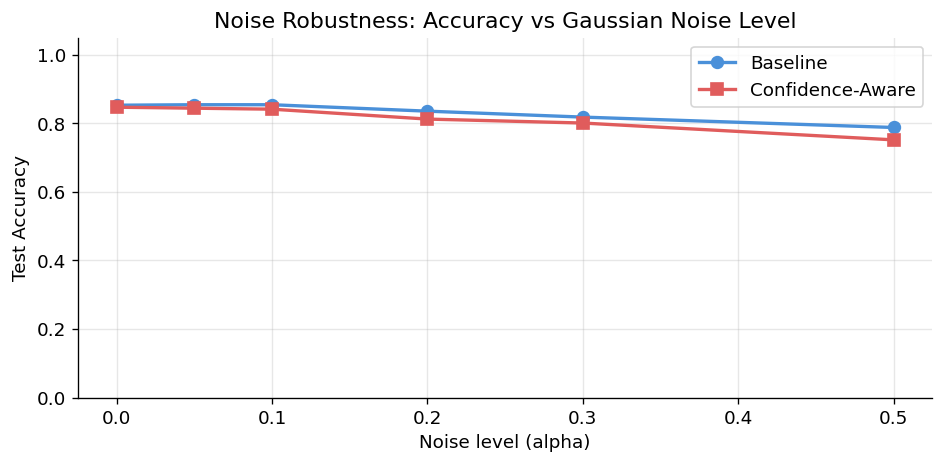

Accuracy drop from clean to alpha=0.5:
  Baseline : 0.8528 -> 0.7879  (drop: 0.0649)
  CA model : 0.8470 -> 0.7518  (drop: 0.0952)


In [59]:
# plot noise robustness
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(noise_levels, bl_noise_accs, 'o-', color='#4a90d9', linewidth=2,
        label='Baseline', markersize=7)
ax.plot(noise_levels, ca_noise_accs, 's-', color='#e05c5c', linewidth=2,
        label='Confidence-Aware', markersize=7)

ax.set_xlabel('Noise level (alpha)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Noise Robustness: Accuracy vs Gaussian Noise Level')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('robustness_noise.png', bbox_inches='tight')
plt.show()

print('Accuracy drop from clean to alpha=0.5:')
print(f'  Baseline : {bl_noise_accs[0]:.4f} -> {bl_noise_accs[-1]:.4f}  (drop: {bl_noise_accs[0]-bl_noise_accs[-1]:.4f})')
print(f'  CA model : {ca_noise_accs[0]:.4f} -> {ca_noise_accs[-1]:.4f}  (drop: {ca_noise_accs[0]-ca_noise_accs[-1]:.4f})')


In [60]:
# --- 15b. Missing modality simulation ---
# Zero out each modality completely and measure accuracy drop
# The CA model should degrade less because it can down-weight bad modalities

bl_missing = {}
ca_missing = {}

for dropped_grp, dropped_indices in MODALITY_GROUPS.items():

    bl_correct, ca_correct, total = 0, 0, 0

    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device).clone()
            yb = yb.to(device)

            # zero out the dropped modality
            Xb[:, :, dropped_indices] = 0.0

            # baseline
            bl_out = model(Xb)
            bl_correct += (bl_out.argmax(1) == yb).sum().item()

            # confidence-aware
            ca_out = ca_model(Xb)
            if isinstance(ca_out, tuple):
                ca_out = ca_out[0]
            ca_correct += (ca_out.argmax(1) == yb).sum().item()

            total += len(yb)

    bl_missing[dropped_grp] = bl_correct / total
    ca_missing[dropped_grp] = ca_correct / total
    print(f'  Drop [{dropped_grp:15s}]  Baseline: {bl_correct/total:.4f}  CA: {ca_correct/total:.4f}')


  Drop [Reactor        ]  Baseline: 0.6075  CA: 0.6436
  Drop [Separator      ]  Baseline: 0.8427  CA: 0.8225
  Drop [Stripper       ]  Baseline: 0.5786  CA: 0.6219
  Drop [Composition    ]  Baseline: 0.5426  CA: 0.4906


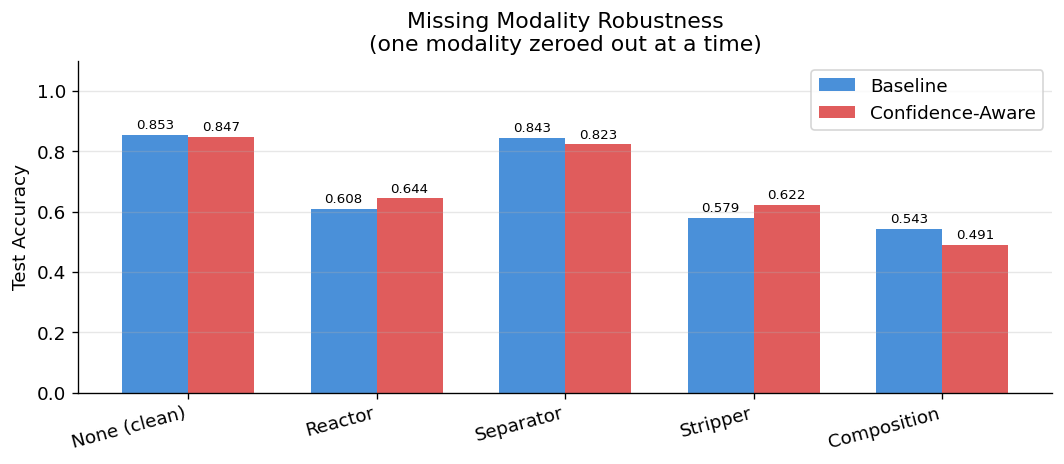


Accuracy drop vs clean baseline:
  Reactor          BL drop: +0.2453  CA drop: +0.2035
  Separator        BL drop: +0.0101  CA drop: +0.0245
  Stripper         BL drop: +0.2742  CA drop: +0.2251
  Composition      BL drop: +0.3102  CA drop: +0.3564


In [61]:
# clean accuracy (no dropout) for reference
bl_clean = accuracy_score(all_labels, all_preds)
ca_clean = accuracy_score(ca_labels, ca_preds)

# plot missing modality results
fig, ax = plt.subplots(figsize=(9, 4))

groups  = ['None (clean)'] + list(MODALITY_GROUPS.keys())
bl_vals = [bl_clean] + [bl_missing[g] for g in MODALITY_GROUPS]
ca_vals = [ca_clean] + [ca_missing[g] for g in MODALITY_GROUPS]

x     = np.arange(len(groups))
width = 0.35

bars1 = ax.bar(x - width/2, bl_vals, width, label='Baseline',
               color='#4a90d9', edgecolor='none')
bars2 = ax.bar(x + width/2, ca_vals, width, label='Confidence-Aware',
               color='#e05c5c', edgecolor='none')

ax.bar_label(bars1, fmt='%.3f', padding=2, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=15, ha='right')
ax.set_ylabel('Test Accuracy')
ax.set_title('Missing Modality Robustness\n(one modality zeroed out at a time)')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('robustness_missing_modality.png', bbox_inches='tight')
plt.show()

print('\nAccuracy drop vs clean baseline:')
for g in MODALITY_GROUPS:
    bl_drop = bl_clean - bl_missing[g]
    ca_drop = ca_clean - ca_missing[g]
    print(f'  {g:15s}  BL drop: {bl_drop:+.4f}  CA drop: {ca_drop:+.4f}')


In [62]:
import torch
torch.cuda.empty_cache()

In [63]:
!pip install shap

import shap
import torch
import numpy as np
import matplotlib.pyplot as plt

In [64]:
def extract_tensor(loader, n_samples=50):
    batch = next(iter(loader))

    if isinstance(batch, (list, tuple)):
        x = batch[0]   # ignore labels
    else:
        x = batch

    return x[:n_samples].to(device)


background = extract_tensor(train_loader, 50)
sample = extract_tensor(test_loader, 10)

In [65]:
SEQ_LEN = background.shape[1]
NUM_FEATURES = background.shape[2]

background_np = background.detach().cpu().numpy().reshape(background.shape[0], -1)
sample_np = sample.detach().cpu().numpy().reshape(sample.shape[0], -1)

In [66]:
def model_predict(x_numpy):
    model_cpu = model.to("cpu")

    x_tensor = torch.tensor(x_numpy, dtype=torch.float32)

    # reshape back
    x_tensor = x_tensor.view(x_numpy.shape[0], SEQ_LEN, NUM_FEATURES)

    with torch.no_grad():
        out = model_cpu(x_tensor)

        if isinstance(out, tuple):
            out = out[0]

    return out.numpy()

In [67]:
explainer = shap.KernelExplainer(model_predict, background_np[:10])
shap_values = explainer.shap_values(sample_np[:2], nsamples=50)

  0%|          | 0/2 [00:00<?, ?it/s]

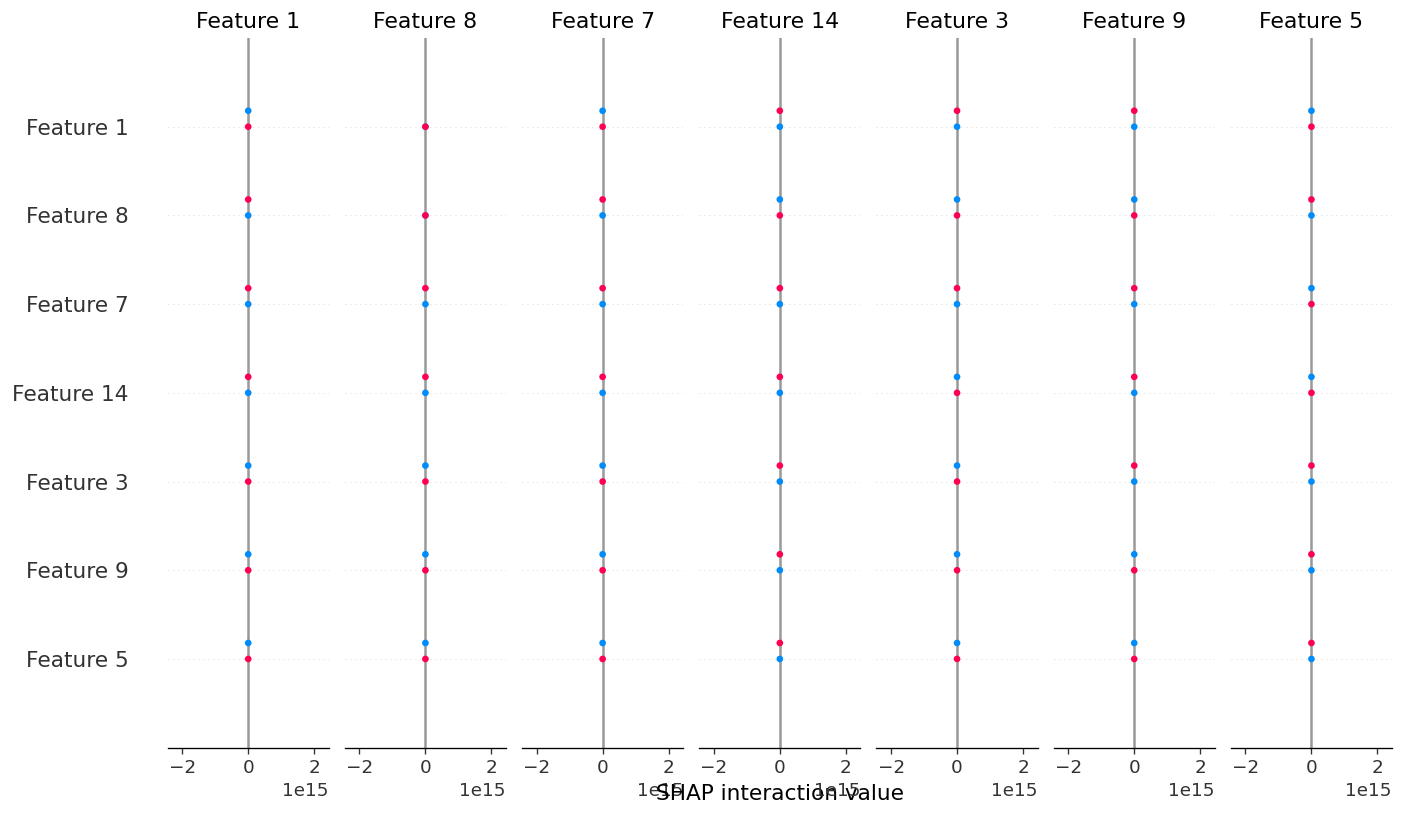

In [68]:
shap.summary_plot(shap_values, sample_np[:2])

## Performance Comparison

In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import torch

In [70]:
def evaluate_model(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            # Handle (x, y)
            if isinstance(batch, (list, tuple)) and len(batch) == 2:
                x, y = batch
                x, y = x.to(device), y.to(device)

                outputs = model(x)

            # Handle multimodal (x1, x2, y)
            elif isinstance(batch, (list, tuple)) and len(batch) == 3:
                x1, x2, y = batch
                x1, x2, y = x1.to(device), x2.to(device), y.to(device)

                outputs = model(x1, x2)

            # Handle other cases
            else:
                continue

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

In [71]:
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    return acc, precision, recall, f1

In [72]:
def evaluate_robustness(model, loader, noise_level=0.01):
    model.eval()

    stable = []

    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, (list, tuple)) and len(batch) == 2:
                x, y = batch
                x = x.to(device)

                noisy_x = x + noise_level * torch.randn_like(x)

                pred1 = torch.argmax(model(x), dim=1)
                pred2 = torch.argmax(model(noisy_x), dim=1)

                stable.append((pred1 == pred2).float().mean().item())

    return np.mean(stable)

In [73]:
# Baseline model
model.to(device)
baseline_preds, labels = evaluate_model(model, test_loader)
baseline_metrics = compute_metrics(labels, baseline_preds)
baseline_robustness = evaluate_robustness(model, test_loader)

# Proposed model (confidence-aware model)
ca_model.to(device)
proposed_preds, _ = evaluate_model(ca_model, test_loader)
proposed_metrics = compute_metrics(labels, proposed_preds)
proposed_robustness = evaluate_robustness(ca_model, test_loader)

In [56]:
print("\n===== MODEL COMPARISON =====\n")

print("Baseline Model:")
print(f"Accuracy  : {baseline_metrics[0]:.4f}")
print(f"Precision : {baseline_metrics[1]:.4f}")
print(f"Recall    : {baseline_metrics[2]:.4f}")
print(f"F1 Score  : {baseline_metrics[3]:.4f}")
print(f"Robustness: {baseline_robustness:.4f}")

print("\nProposed Model:")
print(f"Accuracy  : {proposed_metrics[0]:.4f}")
print(f"Precision : {proposed_metrics[1]:.4f}")
print(f"Recall    : {proposed_metrics[2]:.4f}")
print(f"F1 Score  : {proposed_metrics[3]:.4f}")
print(f"Robustness: {proposed_robustness:.4f}")


===== MODEL COMPARISON =====

Baseline Model:
Accuracy  : 0.8528
Precision : 0.8407
Recall    : 0.8528
F1 Score  : 0.8339
Robustness: 0.9972

Proposed Model:
Accuracy  : 0.8470
Precision : 0.8187
Recall    : 0.8470
F1 Score  : 0.8231
Robustness: 0.9986


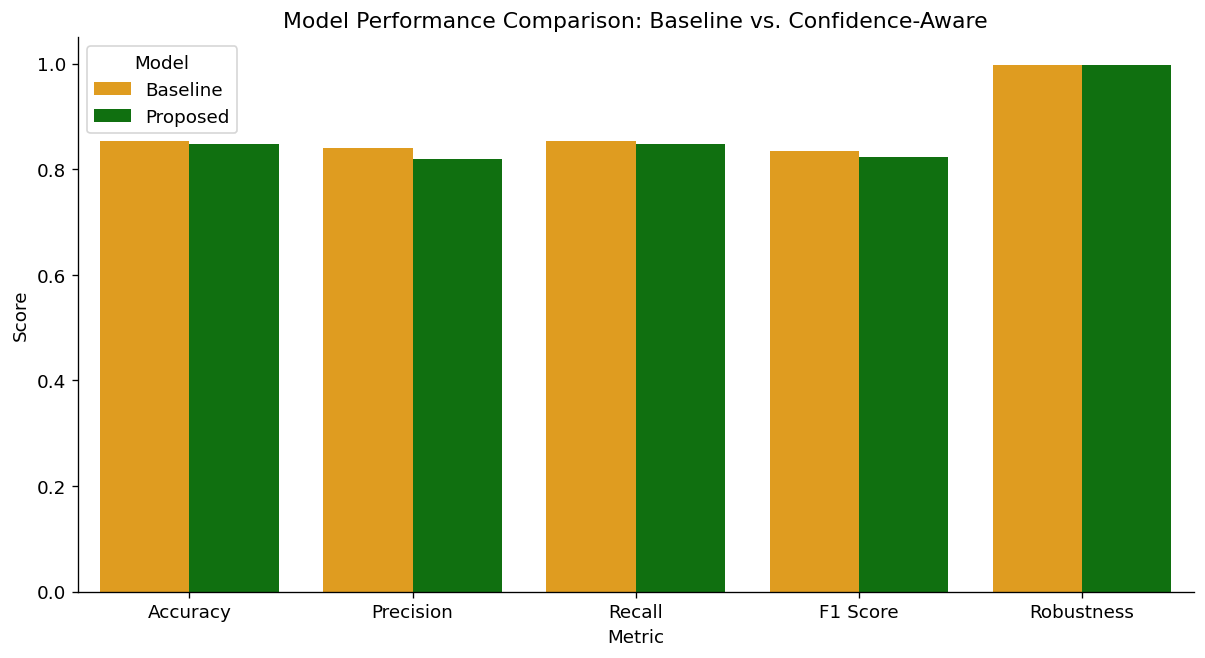

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Robustness']
baseline_values = list(baseline_metrics) + [baseline_robustness]
proposed_values = list(proposed_metrics) + [proposed_robustness]

comparison_df = pd.DataFrame({
    'Metric': metrics,
    'Baseline': baseline_values,
    'Proposed': proposed_values
})

# Reshape for seaborn barplot
comparison_melted = comparison_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

# Define custom palette
custom_palette = {'Baseline': 'orange', 'Proposed': 'green'}

plt.figure(figsize=(12, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_melted, palette=custom_palette)
plt.title('Model Performance Comparison: Baseline vs. Confidence-Aware')
plt.ylabel('Score')
plt.ylim(0.0, 1.05) # Metrics are usually between 0 and 1
plt.show()